# Musanga U-Net — Reloaded Full Model, Classified-Tree Evaluation and Visual Diagnostics

This notebook reuses the saved full U-Net/ResNet-18 checkpoint and persistent patch cache. It does **not retrain by default**. It evaluates the model only inside digitized tree polygons (`Clss_ID = 1` for Musanga; all other values for non-Musanga), searches thresholds down to **0.001**, and exports publication-style diagnostic figures.


## BLOCK 01 — Install dependencies

In [1]:
!pip -q install rasterio pandas numpy albumentations segmentation-models-pytorch matplotlib tqdm geopandas pyogrio scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 10.2 MB/s eta 0:00:00


## BLOCK 02 — Imports, reproducibility, and GPU

In [2]:
from pathlib import Path
import copy
import hashlib
import json
import random
import shutil
import time
import warnings

import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window
from rasterio.features import rasterize
from shapely.geometry import box
import matplotlib.pyplot as plt
import geopandas as gpd
from tqdm.auto import tqdm

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
import segmentation_models_pytorch as smp
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score,
    balanced_accuracy_score, roc_auc_score, average_precision_score,
)

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("DEVICE:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


DEVICE: cuda
GPU: Tesla T4


## BLOCK 03 — Mount Drive and load Notebook 1 configuration

In [3]:
from google.colab import drive

DRIVE_ROOT = Path("/content/drive")
MYDRIVE = DRIVE_ROOT / "MyDrive"

if not MYDRIVE.exists() or not any(MYDRIVE.iterdir()):
    drive.mount(str(DRIVE_ROOT))
else:
    print("Google Drive already mounted:", MYDRIVE)

PROJECT_ROOT = (
    MYDRIVE
    / "Colab Notebooks"
    / "Musanga"
)

CONFIG_PATH = (
    PROJECT_ROOT
    / "work"
    / "project_config.json"
)

assert CONFIG_PATH.exists(), (
    "Missing project_config.json. "
    "Run Notebook 1 first."
)

config = json.loads(
    CONFIG_PATH.read_text()
)

DRIVE_RASTER_PATH = Path(
    config["raster_path"]
)

DRIVE_MASK_PATH = Path(
    config["musanga_mask_path"]
)

PATCH_INDEX_PATH = Path(
    config["patch_index_path"]
)

WORK_DIR = Path(
    config["work_dir"]
)

MODEL_DIR = (
    WORK_DIR
    / "models"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PATCH_SIZE = int(
    config["patch_size"]
)

RGB_BANDS = list(
    config["rgb_bands"]
)

GLOBAL_RGB_LOW = np.asarray(
    config["global_rgb_low"],
    dtype=np.float32,
)

GLOBAL_RGB_HIGH = np.asarray(
    config["global_rgb_high"],
    dtype=np.float32,
)

assert DRIVE_RASTER_PATH.exists(), DRIVE_RASTER_PATH
assert DRIVE_MASK_PATH.exists(), DRIVE_MASK_PATH
assert PATCH_INDEX_PATH.exists(), PATCH_INDEX_PATH

print("Raster:", DRIVE_RASTER_PATH)
print("Mask:", DRIVE_MASK_PATH)
print("Patch index:", PATCH_INDEX_PATH)

Mounted at /content/drive
Raster: /content/drive/MyDrive/Colab Notebooks/Musanga/data/Carlier2020_Aug24_25_survey_transparent_mosaic_group1.tif
Mask: /content/drive/MyDrive/Colab Notebooks/Musanga/work/musanga_reference_mask.tif
Patch index: /content/drive/MyDrive/Colab Notebooks/Musanga/work/indices/musanga_patch_index.csv


## BLOCK 04 — Training and cache configuration

In [4]:
# ======================================================================================
# BLOCK 04 — RELOAD-ONLY EVALUATION CONFIGURATION
# ======================================================================================

# This notebook is now configured to reuse the already-trained full model.
# Set RUN_TRAINING=True only when you deliberately want to train again.
RUN_TRAINING = False
TEST_MODE = False

BATCH_SIZE = 16
NUM_WORKERS = 4

MAX_EPOCHS = 15
PATIENCE = 4
VALIDATE_EVERY = 1
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
THRESHOLD = 0.50

FORCE_REBUILD_PATCH_CACHE = False

ENCODER_NAME = "resnet18"
ENCODER_WEIGHTS = "imagenet"

LOCAL_ROOT = Path("/content/musanga_training")
LOCAL_SOURCE_DIR = LOCAL_ROOT / "sources"
LOCAL_CACHE_ROOT = LOCAL_ROOT / "patch_caches"
LOCAL_SOURCE_DIR.mkdir(parents=True, exist_ok=True)
LOCAL_CACHE_ROOT.mkdir(parents=True, exist_ok=True)

LOCAL_RASTER_PATH = LOCAL_SOURCE_DIR / DRIVE_RASTER_PATH.name
LOCAL_MASK_PATH = LOCAL_SOURCE_DIR / DRIVE_MASK_PATH.name

DRIVE_CACHE_ROOT = WORK_DIR / "patch_cache_archives"
DRIVE_CACHE_ROOT.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = MODEL_DIR / "best_musanga_unet_resnet18_full.pt"
HISTORY_PATH = MODEL_DIR / "training_history_resnet18_full.csv"

print("RUN_TRAINING:", RUN_TRAINING)
print("TEST_MODE:", TEST_MODE)
print("Checkpoint:", CHECKPOINT_PATH)
print("Persistent cache root:", DRIVE_CACHE_ROOT)


RUN_TRAINING: False
TEST_MODE: False
Checkpoint: /content/drive/MyDrive/Colab Notebooks/Musanga/work/models/best_musanga_unet_resnet18_full.pt
Persistent cache root: /content/drive/MyDrive/Colab Notebooks/Musanga/work/patch_cache_archives


## BLOCK 05 — Copy source rasters to local Colab storage

In [5]:
def copy_if_needed(
    source_path,
    destination_path,
):
    source_path = Path(
        source_path
    )

    destination_path = Path(
        destination_path
    )

    needs_copy = (
        not destination_path.exists()
        or destination_path.stat().st_size
        != source_path.stat().st_size
    )

    if needs_copy:
        print(
            "Copying:",
            source_path.name,
        )

        shutil.copy2(
            source_path,
            destination_path,
        )

    else:
        print(
            "Reusing local source:",
            destination_path,
        )


copy_if_needed(
    DRIVE_RASTER_PATH,
    LOCAL_RASTER_PATH,
)

copy_if_needed(
    DRIVE_MASK_PATH,
    LOCAL_MASK_PATH,
)

print("Local raster:", LOCAL_RASTER_PATH)
print("Local mask:", LOCAL_MASK_PATH)

Copying: Carlier2020_Aug24_25_survey_transparent_mosaic_group1.tif
Copying: musanga_reference_mask.tif
Local raster: /content/musanga_training/sources/Carlier2020_Aug24_25_survey_transparent_mosaic_group1.tif
Local mask: /content/musanga_training/sources/musanga_reference_mask.tif


## BLOCK 06 — Load and validate patch index

In [6]:
# ======================================================================================
# BLOCK 06 — LOAD, VALIDATE, AND SUBSET THE PATCH INDEX
# ======================================================================================

full_patch_index = pd.read_csv(PATCH_INDEX_PATH)

required_columns = {
    "patch_id", "row_off", "col_off", "height", "width", "split", "has_musanga"
}
missing_columns = required_columns - set(full_patch_index.columns)
if missing_columns:
    raise ValueError(f"Missing patch-index columns: {sorted(missing_columns)}")

full_patch_index["has_musanga"] = full_patch_index["has_musanga"].astype(bool)

for split_name in ["train", "val", "test"]:
    split_table = full_patch_index[full_patch_index["split"] == split_name]
    if split_table.empty:
        raise ValueError(f"Split {split_name!r} is empty.")
    if not split_table["has_musanga"].any():
        raise ValueError(f"Split {split_name!r} contains no positive patches.")


def balanced_subset(table, maximum, seed):
    """Deterministic near-balanced subset while retaining both classes when available."""
    table = table.copy()
    if maximum is None or len(table) <= maximum:
        return table.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    groups = []
    labels = list(table["has_musanga"].drop_duplicates())
    per_group = maximum // len(labels)

    for label in labels:
        group = table[table["has_musanga"] == label]
        groups.append(group.sample(n=min(per_group, len(group)), random_state=seed))

    chosen = pd.concat(groups).drop_duplicates("patch_id")
    remaining_n = maximum - len(chosen)
    if remaining_n > 0:
        remaining = table[~table["patch_id"].isin(chosen["patch_id"])]
        if not remaining.empty:
            chosen = pd.concat([
                chosen,
                remaining.sample(n=min(remaining_n, len(remaining)), random_state=seed + 1),
            ])

    return chosen.sample(frac=1.0, random_state=seed + 2).reset_index(drop=True)


if TEST_MODE:
    limits = {
        "train": TEST_TRAIN_PATCHES,
        "val": TEST_VAL_PATCHES,
        "test": TEST_TEST_PATCHES,
    }
    patch_index = pd.concat([
        balanced_subset(
            full_patch_index[full_patch_index["split"] == split_name],
            maximum=limit,
            seed=SEED + split_number,
        )
        for split_number, (split_name, limit) in enumerate(limits.items())
    ], ignore_index=True)
else:
    patch_index = full_patch_index.copy()

summary = (
    patch_index.groupby(["split", "has_musanga"])
    .size().rename("n_patches").reset_index()
)
display(summary)

print("Full patch index:", len(full_patch_index))
print("Selected for this run:", len(patch_index))


,split,has_musanga,n_patches
0,test,False,857
1,test,True,476
2,train,False,4653
3,train,True,2372
4,val,False,956
5,val,True,496


Full patch index: 9810
Selected for this run: 9810


## BLOCK 07 — Build the one-time local patch cache

In [7]:
# ======================================================================================
# BLOCK 07 — RESTORE OR BUILD THE PERSISTENT PATCH CACHE
# ======================================================================================

# The fingerprint prevents accidental reuse after changing the source data or test subset.
fingerprint_payload = {
    "test_mode": TEST_MODE,
    "patch_size": PATCH_SIZE,
    "rgb_bands": RGB_BANDS,
    "patch_ids": sorted(patch_index["patch_id"].astype(str).tolist()),
    "raster_name": DRIVE_RASTER_PATH.name,
    "raster_size": DRIVE_RASTER_PATH.stat().st_size,
    "mask_name": DRIVE_MASK_PATH.name,
    "mask_size": DRIVE_MASK_PATH.stat().st_size,
}
cache_fingerprint = hashlib.sha1(
    json.dumps(fingerprint_payload, sort_keys=True).encode("utf-8")
).hexdigest()[:12]

CACHE_NAME = f"{'test' if TEST_MODE else 'full'}_{cache_fingerprint}"
PATCH_CACHE_DIR = LOCAL_CACHE_ROOT / CACHE_NAME
CACHE_INDEX_PATH = PATCH_CACHE_DIR / "cached_patch_index.csv"
CACHE_COMPLETE_PATH = PATCH_CACHE_DIR / "CACHE_COMPLETE.json"
DRIVE_CACHE_ARCHIVE = DRIVE_CACHE_ROOT / f"{CACHE_NAME}.tar"

if FORCE_REBUILD_PATCH_CACHE:
    shutil.rmtree(PATCH_CACHE_DIR, ignore_errors=True)
    if DRIVE_CACHE_ARCHIVE.exists():
        DRIVE_CACHE_ARCHIVE.unlink()

PATCH_CACHE_DIR.mkdir(parents=True, exist_ok=True)


def local_cache_complete():
    if not CACHE_INDEX_PATH.exists() or not CACHE_COMPLETE_PATH.exists():
        return False
    try:
        table = pd.read_csv(CACHE_INDEX_PATH)
        marker = json.loads(CACHE_COMPLETE_PATH.read_text())
    except Exception:
        return False
    if marker.get("fingerprint") != cache_fingerprint or len(table) != len(patch_index):
        return False
    # A few sentinel checks are enough because the archive has an explicit completion marker.
    sentinel_ids = table["patch_id"].astype(str).iloc[[0, len(table)//2, -1]].tolist()
    return all((PATCH_CACHE_DIR / f"{patch_id}.npz").exists() for patch_id in sentinel_ids)


if not local_cache_complete() and DRIVE_CACHE_ARCHIVE.exists():
    print("Restoring persistent cache archive from Google Drive:", DRIVE_CACHE_ARCHIVE)
    shutil.rmtree(PATCH_CACHE_DIR, ignore_errors=True)
    PATCH_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    shutil.unpack_archive(str(DRIVE_CACHE_ARCHIVE), str(PATCH_CACHE_DIR), format="tar")


if local_cache_complete():
    print("Reusing complete local cache:", PATCH_CACHE_DIR)
else:
    print("Building patch cache for", len(patch_index), "selected patches...")
    shutil.rmtree(PATCH_CACHE_DIR, ignore_errors=True)
    PATCH_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    cache_rows = []

    with rasterio.open(LOCAL_RASTER_PATH) as image_src, rasterio.open(LOCAL_MASK_PATH) as label_src:
        for record in tqdm(
            patch_index.itertuples(index=False),
            total=len(patch_index),
            desc="Caching patches",
        ):
            window = Window(
                int(record.col_off), int(record.row_off),
                int(record.width), int(record.height),
            )
            image = image_src.read(
                RGB_BANDS, window=window, boundless=True, fill_value=0
            )
            valid_mask = image_src.dataset_mask(
                window=window, boundless=True
            ) > 0
            musanga_mask = label_src.read(
                1, window=window, boundless=True, fill_value=0
            ) == 1

            height, width = image.shape[1:]
            padded_image = np.zeros((3, PATCH_SIZE, PATCH_SIZE), dtype=image.dtype)
            padded_mask = np.zeros((PATCH_SIZE, PATCH_SIZE), dtype=np.uint8)
            padded_valid = np.zeros((PATCH_SIZE, PATCH_SIZE), dtype=np.uint8)

            padded_image[:, :height, :width] = image[:3]
            padded_mask[:height, :width] = musanga_mask.astype(np.uint8)
            padded_valid[:height, :width] = valid_mask.astype(np.uint8)

            cache_path = PATCH_CACHE_DIR / f"{record.patch_id}.npz"
            # Uncompressed NPZ is deliberately used for faster creation and loading.
            np.savez(
                cache_path,
                image=padded_image,
                mask=padded_mask,
                valid=padded_valid,
            )
            cache_rows.append({
                "patch_id": record.patch_id,
                "split": record.split,
                "has_musanga": bool(record.has_musanga),
                "cache_path": str(cache_path),
            })

    cached_index = pd.DataFrame(cache_rows)
    cached_index.to_csv(CACHE_INDEX_PATH, index=False)
    CACHE_COMPLETE_PATH.write_text(json.dumps({
        "fingerprint": cache_fingerprint,
        "n_patches": len(cached_index),
        "created": pd.Timestamp.utcnow().isoformat(),
    }, indent=2))

    print("Saving one persistent cache archive to Google Drive...")
    temporary_archive = LOCAL_CACHE_ROOT / f"{CACHE_NAME}.tar"
    if temporary_archive.exists():
        temporary_archive.unlink()
    shutil.make_archive(
        str(temporary_archive.with_suffix("")),
        format="tar",
        root_dir=PATCH_CACHE_DIR,
    )
    shutil.copy2(temporary_archive, DRIVE_CACHE_ARCHIVE)
    temporary_archive.unlink()
    print("Saved persistent cache:", DRIVE_CACHE_ARCHIVE)

cached_index = pd.read_csv(CACHE_INDEX_PATH)
# Always rewrite paths after restoring on a new Colab runtime.
cached_index["cache_path"] = cached_index["patch_id"].astype(str).map(
    lambda patch_id: str(PATCH_CACHE_DIR / f"{patch_id}.npz")
)

print("Cached patches:", len(cached_index))
print("Local cache:", PATCH_CACHE_DIR)


Restoring persistent cache archive from Google Drive: /content/drive/MyDrive/Colab Notebooks/Musanga/work/patch_cache_archives/full_7c5c4dd5d92c.tar
Reusing complete local cache: /content/musanga_training/patch_caches/full_7c5c4dd5d92c
Cached patches: 9810
Local cache: /content/musanga_training/patch_caches/full_7c5c4dd5d92c


## BLOCK 08 — Global RGB normalization

In [8]:
def normalize_rgb_global(
    image_chw,
):
    image_chw = image_chw.astype(
        np.float32
    )

    output = np.zeros_like(
        image_chw,
        dtype=np.float32,
    )

    for channel in range(3):
        low = GLOBAL_RGB_LOW[
            channel
        ]

        high = GLOBAL_RGB_HIGH[
            channel
        ]

        output[channel] = np.clip(
            (
                image_chw[channel]
                - low
            )
            / max(
                high - low,
                1e-6,
            ),
            0,
            1,
        )

    return output

## BLOCK 09 — Cached Dataset

In [9]:
class MusangaCachedDataset(
    Dataset
):
    def __init__(
        self,
        table,
        augment=None,
    ):
        self.table = table.reset_index(
            drop=True
        )

        self.augment = augment


    def __len__(
        self,
    ):
        return len(
            self.table
        )


    def __getitem__(
        self,
        index,
    ):
        record = self.table.iloc[
            index
        ]

        with np.load(
            record.cache_path
        ) as data:
            image = data[
                "image"
            ]
            mask = data[
                "mask"
            ]
            valid = data[
                "valid"
            ]

        image = normalize_rgb_global(
            image
        )

        image_hwc = np.moveaxis(
            image,
            0,
            -1,
        )

        if self.augment is not None:
            transformed = self.augment(
                image=image_hwc,
                masks=[
                    mask,
                    valid,
                ],
            )

            image_hwc = transformed[
                "image"
            ]

            mask = transformed[
                "masks"
            ][0]

            valid = transformed[
                "masks"
            ][1]

        image_tensor = torch.from_numpy(
            np.moveaxis(
                np.ascontiguousarray(
                    image_hwc
                ),
                -1,
                0,
            )
        ).float()

        mask_tensor = torch.from_numpy(
            np.ascontiguousarray(
                mask[
                    None,
                    ...,
                ]
            )
        ).float()

        valid_tensor = torch.from_numpy(
            np.ascontiguousarray(
                valid[
                    None,
                    ...,
                ]
            )
        ).float()

        return {
            "image": image_tensor,
            "mask": mask_tensor,
            "valid_mask": valid_tensor,
            "patch_id": record.patch_id,
        }

## BLOCK 10 — Data augmentation

In [10]:
train_augmentation = A.Compose([
    A.HorizontalFlip(
        p=0.5
    ),
    A.VerticalFlip(
        p=0.5
    ),
    A.RandomRotate90(
        p=0.5
    ),
    A.OneOf([
        A.RandomBrightnessContrast(
            brightness_limit=0.12,
            contrast_limit=0.12,
            p=1.0,
        ),
        A.HueSaturationValue(
            hue_shift_limit=6,
            sat_shift_limit=10,
            val_shift_limit=10,
            p=1.0,
        ),
    ], p=0.35),
    A.OneOf([
        A.GaussianBlur(
            blur_limit=(3, 5),
            p=1.0,
        ),
        A.GaussNoise(
            std_range=(
                0.01,
                0.035,
            ),
            p=1.0,
        ),
    ], p=0.10),
])

## BLOCK 11 — DataLoaders

In [11]:
# ======================================================================================
# BLOCK 11 — DATALOADERS
# ======================================================================================

train_table = cached_index.query("split == 'train'").copy()
validation_table = cached_index.query("split == 'val'").copy()
test_table = cached_index.query("split == 'test'").copy()

train_dataset = MusangaCachedDataset(train_table, augment=train_augmentation)
validation_dataset = MusangaCachedDataset(validation_table, augment=None)
test_dataset = MusangaCachedDataset(test_table, augment=None)

loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": torch.cuda.is_available(),
    "persistent_workers": NUM_WORKERS > 0,
}
if NUM_WORKERS > 0:
    loader_kwargs["prefetch_factor"] = 2

train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
validation_loader = DataLoader(validation_dataset, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

print("Train / validation / test:", len(train_dataset), len(validation_dataset), len(test_dataset))
print("Train batches per epoch:", len(train_loader))


Train / validation / test: 7025 1452 1333
Train batches per epoch: 440


## BLOCK 12 — Time the cached DataLoader

In [12]:
# ======================================================================================
# BLOCK 12 — TIME THE CACHED DATALOADER
# ======================================================================================

timing_start = time.time()
n_timing_batches = min(10 if TEST_MODE else 20, len(train_loader))
loaded_batches = 0

for batch_index, batch in enumerate(train_loader):
    if batch_index >= n_timing_batches:
        break
    loaded_batches += 1

elapsed = time.time() - timing_start
print(f"{loaded_batches} cached batches loaded in {elapsed:.2f} seconds")
print("Seconds per cached batch:", elapsed / max(loaded_batches, 1))


20 cached batches loaded in 9.98 seconds
Seconds per cached batch: 0.49914391040802003


## BLOCK 13 — Visual quality control

In [13]:
positive_qc = train_table[
    train_table[
        "has_musanga"
    ]
    == True
].sample(
    n=min(
        3,
        (
            train_table[
                "has_musanga"
            ]
            == True
        ).sum(),
    ),
    random_state=SEED,
)

negative_qc = train_table[
    train_table[
        "has_musanga"
    ]
    == False
].sample(
    n=min(
        1,
        (
            train_table[
                "has_musanga"
            ]
            == False
        ).sum(),
    ),
    random_state=SEED,
)

qc_table = pd.concat(
    [
        positive_qc,
        negative_qc,
    ],
    ignore_index=True,
)

qc_loader = DataLoader(
    MusangaCachedDataset(
        qc_table,
        augment=None,
    ),
    batch_size=len(qc_table),
    shuffle=False,
    num_workers=0,
)

qc_batch = next(
    iter(qc_loader)
)

n_examples = qc_batch[
    "image"
].shape[0]

figure, axes = plt.subplots(
    n_examples,
    3,
    figsize=(
        15,
        5 * n_examples,
    ),
)

if n_examples == 1:
    axes = np.array([
        axes
    ])

for row in range(
    n_examples
):
    rgb = np.moveaxis(
        qc_batch[
            "image"
        ][row].numpy(),
        0,
        -1,
    )

    mask = qc_batch[
        "mask"
    ][row, 0].numpy()

    valid = (
        qc_batch[
            "valid_mask"
        ][row, 0]
        .numpy()
        .astype(bool)
    )

    rgb[
        ~valid
    ] = 1.0

    overlay = rgb.copy()

    positive = (
        mask >= 0.5
    )

    overlay[
        positive,
        0,
    ] = 1.0

    overlay[
        positive,
        1,
    ] *= 0.35

    overlay[
        positive,
        2,
    ] *= 0.35

    axes[row, 0].imshow(
        rgb
    )

    axes[row, 0].set_title(
        qc_batch[
            "patch_id"
        ][row]
    )

    axes[row, 1].imshow(
        overlay
    )

    axes[row, 1].set_title(
        "Musanga overlay"
    )

    axes[row, 2].imshow(
        mask,
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    axes[row, 2].set_title(
        "Musanga mask"
    )

    for axis in axes[row]:
        axis.axis("off")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## BLOCK 14 — Model, loss, optimizer, and scheduler

In [14]:
model = smp.Unet(
    encoder_name=ENCODER_NAME,
    encoder_weights=ENCODER_WEIGHTS,
    in_channels=3,
    classes=1,
    activation=None,
).to(DEVICE)

bce_loss = nn.BCEWithLogitsLoss(
    reduction="none"
)


def masked_dice_loss(
    logits,
    targets,
    valid_mask,
    eps=1e-7,
):
    probabilities = torch.sigmoid(
        logits
    )

    probabilities = (
        probabilities
        * valid_mask
    )

    targets = (
        targets
        * valid_mask
    )

    intersection = (
        probabilities
        * targets
    ).sum(
        dim=(
            1,
            2,
            3,
        )
    )

    denominator = (
        probabilities.sum(
            dim=(
                1,
                2,
                3,
            )
        )
        + targets.sum(
            dim=(
                1,
                2,
                3,
            )
        )
    )

    dice = (
        2 * intersection
        + eps
    ) / (
        denominator
        + eps
    )

    return (
        1 - dice
    ).mean()


def criterion(
    logits,
    targets,
    valid_mask,
):
    pixel_bce = bce_loss(
        logits,
        targets,
    )

    masked_bce = (
        pixel_bce
        * valid_mask
    ).sum() / valid_mask.sum().clamp_min(
        1.0
    )

    dice = masked_dice_loss(
        logits,
        targets,
        valid_mask,
    )

    return (
        0.5 * masked_bce
        + 0.5 * dice
    )


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available(),
)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 46.8MB            

model.safetensors: downloading bytes:           |  0.00B            

## BLOCK 15 — Metrics and epoch runner

In [15]:
# ======================================================================================
# BLOCK 15 — METRICS AND MEMORY-EFFICIENT EPOCH RUNNER
# ======================================================================================

@torch.no_grad()
def batch_counts(logits, targets, valid_mask, threshold=0.5):
    probabilities = torch.sigmoid(logits)
    predictions = probabilities >= threshold
    truth = targets >= 0.5
    valid = valid_mask >= 0.5

    tp = (predictions & truth & valid).sum().item()
    fp = (predictions & ~truth & valid).sum().item()
    fn = (~predictions & truth & valid).sum().item()
    tn = (~predictions & ~truth & valid).sum().item()
    return tp, fp, fn, tn


def summarize_counts(tp, fp, fn, tn, eps=1e-8):
    return {
        "precision": tp / (tp + fp + eps),
        "recall": tp / (tp + fn + eps),
        "dice": (2 * tp) / (2 * tp + fp + fn + eps),
        "iou": tp / (tp + fp + fn + eps),
        "accuracy": (tp + tn) / (tp + fp + fn + tn + eps),
    }


def run_epoch(loader, training):
    model.train(training)
    total_loss = 0.0
    total_items = 0
    counts = np.zeros(4, dtype=np.float64)
    iterator = tqdm(loader, leave=False)

    # Validation uses inference_mode, so no graph is created and GPU memory remains low.
    grad_context = torch.enable_grad() if training else torch.inference_mode()
    with grad_context:
        for batch in iterator:
            images = batch["image"].to(DEVICE, non_blocking=True)
            masks = batch["mask"].to(DEVICE, non_blocking=True)
            valid_mask = batch["valid_mask"].to(DEVICE, non_blocking=True)

            if training:
                optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                logits = model(images)
                loss = criterion(logits, masks, valid_mask)

            if training:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()

            batch_size = images.shape[0]
            total_loss += float(loss.item()) * batch_size
            total_items += batch_size
            counts += np.asarray(batch_counts(
                logits.detach(), masks, valid_mask, THRESHOLD
            ))
            iterator.set_postfix(loss=f"{loss.item():.4f}")

    metrics = summarize_counts(*counts)
    metrics["loss"] = total_loss / max(total_items, 1)
    return metrics


## BLOCK 16 — Train with early stopping

In [16]:
# ======================================================================================
# BLOCK 16 — OPTIONAL TRAINING
# ======================================================================================

if not RUN_TRAINING:
    print("RUN_TRAINING=False: skipping training and keeping the saved full checkpoint.")
    history = []
else:
    history = []

    best_state = None
    best_validation_dice = -np.inf

    validation_checks_without_improvement = 0

    for epoch in range(
        1,
        MAX_EPOCHS + 1,
    ):
        epoch_start = time.time()

        train_metrics = run_epoch(
            train_loader,
            training=True,
        )

        run_validation = (
            epoch == 1
            or epoch % VALIDATE_EVERY == 0
            or epoch == MAX_EPOCHS
        )

        validation_metrics = None

        if run_validation:
            validation_metrics = run_epoch(
                validation_loader,
                training=False,
            )

            scheduler.step(
                validation_metrics[
                    "dice"
                ]
            )

        row = {
            "epoch": epoch,
            "seconds": (
                time.time()
                - epoch_start
            ),
            "learning_rate": optimizer.param_groups[
                0
            ]["lr"],
            **{
                f"train_{key}": value
                for key, value
                in train_metrics.items()
            },
        }

        if validation_metrics is not None:
            row.update({
                f"val_{key}": value
                for key, value
                in validation_metrics.items()
            })

        history.append(
            row
        )

        pd.DataFrame(
            history
        ).to_csv(
            HISTORY_PATH,
            index=False,
        )

        if validation_metrics is None:
            print(
                f"Epoch {epoch:03d} | "
                f"train loss={train_metrics['loss']:.4f}, "
                f"dice={train_metrics['dice']:.4f} | "
                "validation skipped"
            )

            continue

        print(
            f"Epoch {epoch:03d} | "
            f"train loss={train_metrics['loss']:.4f}, "
            f"dice={train_metrics['dice']:.4f} | "
            f"val loss={validation_metrics['loss']:.4f}, "
            f"dice={validation_metrics['dice']:.4f}, "
            f"IoU={validation_metrics['iou']:.4f}"
        )

        improved = (
            validation_metrics[
                "dice"
            ]
            > best_validation_dice
            + 1e-4
        )

        if improved:
            best_validation_dice = (
                validation_metrics[
                    "dice"
                ]
            )

            best_state = copy.deepcopy(
                model.state_dict()
            )

            validation_checks_without_improvement = 0

            torch.save(
                {
                    "model_state_dict": best_state,
                    "encoder_name": ENCODER_NAME,
                    "encoder_weights": ENCODER_WEIGHTS,
                    "patch_size": PATCH_SIZE,
                    "rgb_bands": RGB_BANDS,
                    "global_rgb_low": GLOBAL_RGB_LOW.tolist(),
                    "global_rgb_high": GLOBAL_RGB_HIGH.tolist(),
                    "threshold": THRESHOLD,
                    "best_val_dice": best_validation_dice,
                    "test_mode": TEST_MODE,
                    "selected_patch_count": len(patch_index),
                    "cache_fingerprint": cache_fingerprint,
                    "config": config,
                },
                CHECKPOINT_PATH,
            )

            print(
                "Saved best checkpoint:",
                CHECKPOINT_PATH,
            )

        else:
            validation_checks_without_improvement += 1

        if (
            validation_checks_without_improvement
            >= PATIENCE
        ):
            print(
                "Early stopping after",
                validation_checks_without_improvement,
                "validation checks without improvement.",
            )
            break

    if best_state is None:
        raise RuntimeError(
            "No best checkpoint was created."
        )

    model.load_state_dict(
        best_state
    )


RUN_TRAINING=False: skipping training and keeping the saved full checkpoint.


## BLOCK 17 — Plot training history

In [17]:
# ======================================================================================
# BLOCK 17 — OPTIONAL TRAINING HISTORY PLOTS
# ======================================================================================

if not RUN_TRAINING:
    print("Training was skipped; no new history plot is required.")
elif not history:
    print("No training history is available.")
else:
    history_df = pd.DataFrame(
        history
    )

    plt.figure(
        figsize=(9, 5)
    )

    plt.plot(
        history_df["epoch"],
        history_df["train_loss"],
        label="train loss",
    )

    if "val_loss" in history_df.columns:
        validation_rows = history_df[
            history_df[
                "val_loss"
            ].notna()
        ]

        plt.plot(
            validation_rows["epoch"],
            validation_rows["val_loss"],
            marker="o",
            label="validation loss",
        )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


    plt.figure(
        figsize=(9, 5)
    )

    plt.plot(
        history_df["epoch"],
        history_df["train_dice"],
        label="train Dice",
    )

    if "val_dice" in history_df.columns:
        validation_rows = history_df[
            history_df[
                "val_dice"
            ].notna()
        ]

        plt.plot(
            validation_rows["epoch"],
            validation_rows["val_dice"],
            marker="o",
            label="validation Dice",
        )

    plt.xlabel("Epoch")
    plt.ylabel("Dice")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


Training was skipped; no new history plot is required.


## BLOCK 18 — Final test-set metrics

In [18]:
# ======================================================================================
# BLOCK 18 — RECREATE MODEL ARCHITECTURE AND RELOAD THE SAVED FULL MODEL
# ======================================================================================

print("\n" + "=" * 100)
print("BLOCK 18 — RECREATE MODEL ARCHITECTURE AND RELOAD THE SAVED FULL MODEL")
print("=" * 100)

import torch
import segmentation_models_pytorch as smp


# ----------------------------------------------------------------------
# SAFE DEFAULTS REQUIRED TO RECREATE THE TRAINED MODEL ARCHITECTURE
# ----------------------------------------------------------------------

if "DEVICE" not in globals():
    DEVICE = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

if "ENCODER_NAME" not in globals():
    ENCODER_NAME = "resnet18"

# The pretrained encoder weights are not required here because the complete
# trained model weights are loaded immediately afterward.
ENCODER_WEIGHTS_FOR_RELOAD = None

if "CHECKPOINT_PATH" not in globals():
    CHECKPOINT_PATH = (
        MODEL_DIR
        / "best_musanga_unet_resnet18_full.pt"
    )

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Saved full checkpoint not found:\n{CHECKPOINT_PATH}"
    )


print("Device:", DEVICE)
print("Encoder:", ENCODER_NAME)
print("Checkpoint:", CHECKPOINT_PATH)


# ----------------------------------------------------------------------
# RECREATE EXACT MODEL ARCHITECTURE
# ----------------------------------------------------------------------

model = smp.Unet(
    encoder_name=ENCODER_NAME,
    encoder_weights=ENCODER_WEIGHTS_FOR_RELOAD,
    in_channels=3,
    classes=1,
)

model = model.to(DEVICE)


# ----------------------------------------------------------------------
# LOAD SAVED TRAINED CHECKPOINT
# ----------------------------------------------------------------------

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False,
)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model_state_dict = checkpoint["model_state_dict"]
else:
    # Also supports checkpoints containing only the state dictionary.
    model_state_dict = checkpoint


load_result = model.load_state_dict(
    model_state_dict,
    strict=True,
)

model.eval()


print("\nCheckpoint loaded successfully.")
print("State-dict result:", load_result)

if isinstance(checkpoint, dict):

    if "epoch" in checkpoint:
        print("Saved epoch:", checkpoint["epoch"])

    if "val_dice" in checkpoint:
        print(
            "Saved validation Dice:",
            float(checkpoint["val_dice"]),
        )

print("\nModel is ready for evaluation.")


BLOCK 18 — RECREATE MODEL ARCHITECTURE AND RELOAD THE SAVED FULL MODEL
Device: cuda
Encoder: resnet18
Checkpoint: /content/drive/MyDrive/Colab Notebooks/Musanga/work/models/best_musanga_unet_resnet18_full.pt

Checkpoint loaded successfully.
State-dict result: <All keys matched successfully>

Model is ready for evaluation.


## BLOCK 19 — Test prediction examples

In [19]:
# ======================================================================================
# BLOCK 19 — FIND AND LOAD THE CLASSIFIED TREE SHAPEFILE
# ======================================================================================

print("\n" + "=" * 100)
print("BLOCK 19 — FIND AND LOAD THE CLASSIFIED TREE SHAPEFILE")
print("=" * 100)

# Search likely data locations. Cadre_allSite_buf.shp is deliberately excluded:
# this evaluation uses the original classified tree polygons themselves.
search_roots = [
    PROJECT_ROOT / "data",
    PROJECT_ROOT,
    DRIVE_RASTER_PATH.parent,
    PATCH_INDEX_PATH.parent,
]

candidate_paths = []
for root in search_roots:
    if root.exists():
        candidate_paths.extend(root.rglob("*.shp"))

candidate_paths = sorted(set(candidate_paths))
classified_candidates = []

for shp_path in candidate_paths:
    if shp_path.name.lower() == "cadre_allsite_buf.shp":
        continue
    try:
        preview = gpd.read_file(shp_path, rows=5)
        if "Clss_ID" in preview.columns:
            classified_candidates.append(shp_path)
    except Exception:
        pass

if not classified_candidates:
    print("Shapefiles found:")
    for path in candidate_paths:
        print(" -", path)
    raise FileNotFoundError(
        "No shapefile containing the field 'Clss_ID' was found. "
        "Set TREE_SHAPEFILE_PATH manually in this block."
    )

if len(classified_candidates) > 1:
    print("Multiple classified shapefiles found; using the first one:")
    for path in classified_candidates:
        print(" -", path)

TREE_SHAPEFILE_PATH = classified_candidates[0]
trees = gpd.read_file(TREE_SHAPEFILE_PATH)

trees = trees.loc[
    trees.geometry.notna() & ~trees.geometry.is_empty
].copy()

trees["reference_class"] = (trees["Clss_ID"] == 1).astype(np.uint8)
trees["tree_id"] = np.arange(len(trees), dtype=np.int64)

with rasterio.open(LOCAL_RASTER_PATH) as src:
    raster_crs = src.crs

if trees.crs is None:
    raise ValueError("The classified tree shapefile has no CRS.")
if raster_crs is None:
    raise ValueError("The RGB raster has no CRS.")
if trees.crs != raster_crs:
    trees = trees.to_crs(raster_crs)

print("Classified tree shapefile:", TREE_SHAPEFILE_PATH)
print("Total digitized trees:", len(trees))
print("Musanga (Clss_ID = 1):", int(trees["reference_class"].sum()))
print("Non-Musanga (Clss_ID != 1):", int((trees["reference_class"] == 0).sum()))

display(
    trees["Clss_ID"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("Clss_ID")
    .reset_index(name="n_trees")
)



BLOCK 19 — FIND AND LOAD THE CLASSIFIED TREE SHAPEFILE
Classified tree shapefile: /content/drive/MyDrive/Colab Notebooks/Musanga/data/Sample_Musanga_others_2020_2024_complet.shp
Total digitized trees: 7374
Musanga (Clss_ID = 1): 3971
Non-Musanga (Clss_ID != 1): 3403


,Clss_ID,n_trees
0,1.0,3971
1,2.0,3106
2,3.0,210
3,4.0,18
4,5.0,23
5,6.0,30
6,21.0,1
7,NaN,15


# Threshold testing

In [20]:
# ======================================================================================
# BLOCK 20 — COLLECT MODEL PROBABILITIES ONLY INSIDE DIGITIZED TREE POLYGONS
# ======================================================================================

print("\n" + "=" * 100)
print("BLOCK 20 — COLLECT MODEL PROBABILITIES ONLY INSIDE DIGITIZED TREE POLYGONS")
print("=" * 100)

from shapely.geometry import box
from rasterio.features import rasterize
from rasterio.windows import Window
from tqdm.auto import tqdm

import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
import torch


# ----------------------------------------------------------------------
# VALIDATE REQUIRED OBJECTS
# ----------------------------------------------------------------------

required_objects = [
    "model",
    "validation_loader",
    "test_loader",
    "full_patch_index",
    "trees",
    "LOCAL_RASTER_PATH",
    "DEVICE",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Block 20 requires objects that are not available:\n"
        f"{missing_objects}\n"
        "Rerun the setup, DataLoader, model-reload, and tree-shapefile blocks."
    )


required_patch_columns = {
    "patch_id",
    "row_off",
    "col_off",
    "height",
    "width",
    "split",
}

missing_patch_columns = (
    required_patch_columns
    - set(full_patch_index.columns)
)

if missing_patch_columns:
    raise ValueError(
        "full_patch_index is missing required spatial columns:\n"
        f"{sorted(missing_patch_columns)}"
    )


if "reference_class" not in trees.columns:
    raise ValueError(
        "The trees GeoDataFrame does not contain 'reference_class'. "
        "Run the tree-shapefile loading block first."
    )


# ----------------------------------------------------------------------
# CREATE ONE SPATIAL LOOKUP FROM THE ORIGINAL PATCH INDEX
# ----------------------------------------------------------------------

spatial_patch_table = (
    full_patch_index[
        [
            "patch_id",
            "split",
            "row_off",
            "col_off",
            "height",
            "width",
        ]
    ]
    .drop_duplicates(
        subset="patch_id",
        keep="first",
    )
    .copy()
)

if spatial_patch_table["patch_id"].duplicated().any():
    raise ValueError(
        "Duplicate patch_id values remain in spatial_patch_table."
    )

patch_spatial_lookup = spatial_patch_table.set_index(
    "patch_id"
)

print(
    "Patch locations available:",
    f"{len(patch_spatial_lookup):,}",
)


# ----------------------------------------------------------------------
# HELPER: COLLECT PROBABILITIES INSIDE DIGITIZED POLYGONS
# ----------------------------------------------------------------------

def collect_labelled_tree_pixels(
    loader,
    split_name,
):
    """
    Evaluate only pixels covered by digitized tree polygons.

    Reference definition
    --------------------
    Clss_ID == 1:
        Positive Musanga pixels.

    Clss_ID != 1:
        Negative non-Musanga-tree pixels.

    Pixels outside all digitized tree polygons:
        Ignored completely.
    """

    probability_parts = []
    reference_parts = []
    patch_summaries = []

    n_loader_patches = 0
    n_patches_without_trees = 0
    n_patches_with_tree_pixels = 0

    model.eval()

    with rasterio.open(
        LOCAL_RASTER_PATH
    ) as raster_src, torch.inference_mode():

        for batch in tqdm(
            loader,
            desc=f"{split_name}: classified-tree inference",
        ):

            images = batch["image"].to(
                DEVICE,
                non_blocking=True,
            )

            logits = model(images)

            if isinstance(logits, dict):
                logits = logits.get(
                    "out",
                    logits.get("logits"),
                )

            if hasattr(logits, "logits"):
                logits = logits.logits

            batch_probabilities = torch.sigmoid(
                logits
            ).detach().cpu().numpy()[:, 0]

            batch_patch_ids = [
                str(value)
                for value in batch["patch_id"]
            ]

            for batch_row, patch_id in enumerate(
                batch_patch_ids
            ):

                n_loader_patches += 1

                if patch_id not in patch_spatial_lookup.index:
                    raise KeyError(
                        f"Patch {patch_id!r} is missing from full_patch_index."
                    )

                record = patch_spatial_lookup.loc[
                    patch_id
                ]

                record_split = str(
                    record["split"]
                )

                expected_split_names = {
                    "validation": "val",
                    "test": "test",
                }

                expected_split = expected_split_names.get(
                    split_name,
                    split_name,
                )

                if record_split != expected_split:
                    raise ValueError(
                        f"Patch {patch_id!r} has split {record_split!r}, "
                        f"but it was found in the {split_name!r} loader."
                    )

                row_off = int(
                    record["row_off"]
                )

                col_off = int(
                    record["col_off"]
                )

                height = int(
                    record["height"]
                )

                width = int(
                    record["width"]
                )

                window = Window(
                    col_off=col_off,
                    row_off=row_off,
                    width=width,
                    height=height,
                )

                window_transform = raster_src.window_transform(
                    window
                )

                xmin, ymin, xmax, ymax = rasterio.windows.bounds(
                    window,
                    raster_src.transform,
                )

                patch_geometry = box(
                    xmin,
                    ymin,
                    xmax,
                    ymax,
                )

                candidate_indices = list(
                    trees.sindex.intersection(
                        patch_geometry.bounds
                    )
                )

                if not candidate_indices:
                    n_patches_without_trees += 1
                    continue

                patch_trees = trees.iloc[
                    candidate_indices
                ].copy()

                patch_trees = patch_trees[
                    patch_trees.intersects(
                        patch_geometry
                    )
                ].copy()

                if patch_trees.empty:
                    n_patches_without_trees += 1
                    continue

                # ------------------------------------------------------
                # MASK OF ALL DIGITIZED TREE POLYGONS
                # ------------------------------------------------------

                labelled_tree_mask = rasterize(
                    [
                        (
                            geometry,
                            1,
                        )
                        for geometry in patch_trees.geometry
                        if geometry is not None
                        and not geometry.is_empty
                    ],
                    out_shape=(
                        height,
                        width,
                    ),
                    transform=window_transform,
                    fill=0,
                    dtype=np.uint8,
                    all_touched=False,
                ).astype(bool)

                # ------------------------------------------------------
                # POSITIVE MASK: ONLY Clss_ID == 1
                # ------------------------------------------------------

                musanga_trees = patch_trees[
                    patch_trees["reference_class"] == 1
                ]

                if musanga_trees.empty:

                    positive_mask = np.zeros(
                        (
                            height,
                            width,
                        ),
                        dtype=bool,
                    )

                else:

                    positive_mask = rasterize(
                        [
                            (
                                geometry,
                                1,
                            )
                            for geometry in musanga_trees.geometry
                            if geometry is not None
                            and not geometry.is_empty
                        ],
                        out_shape=(
                            height,
                            width,
                        ),
                        transform=window_transform,
                        fill=0,
                        dtype=np.uint8,
                        all_touched=False,
                    ).astype(bool)

                # ------------------------------------------------------
                # ORIGINAL RASTER-VALID MASK FROM THE CACHED DATASET
                # ------------------------------------------------------

                raster_valid = (
                    batch[
                        "valid_mask"
                    ][
                        batch_row,
                        0,
                        :height,
                        :width,
                    ]
                    .detach()
                    .cpu()
                    .numpy()
                    >= 0.5
                )

                evaluation_mask = (
                    labelled_tree_mask
                    & raster_valid
                )

                if not evaluation_mask.any():
                    continue

                patch_probability = batch_probabilities[
                    batch_row,
                    :height,
                    :width,
                ]

                patch_reference = positive_mask.astype(
                    np.uint8
                )

                probability_parts.append(
                    patch_probability[
                        evaluation_mask
                    ].astype(np.float32)
                )

                reference_parts.append(
                    patch_reference[
                        evaluation_mask
                    ].astype(np.uint8)
                )

                n_patches_with_tree_pixels += 1

                patch_summaries.append(
                    {
                        "split": split_name,
                        "patch_id": patch_id,
                        "n_evaluated_pixels": int(
                            evaluation_mask.sum()
                        ),
                        "n_positive_pixels": int(
                            patch_reference[
                                evaluation_mask
                            ].sum()
                        ),
                        "n_negative_pixels": int(
                            (
                                patch_reference[
                                    evaluation_mask
                                ] == 0
                            ).sum()
                        ),
                        "n_tree_polygons": int(
                            len(patch_trees)
                        ),
                        "n_musanga_polygons": int(
                            (
                                patch_trees[
                                    "reference_class"
                                ] == 1
                            ).sum()
                        ),
                        "n_non_musanga_polygons": int(
                            (
                                patch_trees[
                                    "reference_class"
                                ] == 0
                            ).sum()
                        ),
                    }
                )

    if not probability_parts:
        raise RuntimeError(
            f"No digitized tree pixels intersected the {split_name} patches.\n"
            "Check the raster/shapefile CRS, patch locations, and split coverage."
        )

    probabilities = np.concatenate(
        probability_parts
    )

    references = np.concatenate(
        reference_parts
    )

    summary_table = pd.DataFrame(
        patch_summaries
    )

    print(
        f"\n{split_name.capitalize()} collection summary:"
    )

    print(
        "  Loader patches:",
        f"{n_loader_patches:,}",
    )

    print(
        "  Patches without intersecting digitized trees:",
        f"{n_patches_without_trees:,}",
    )

    print(
        "  Patches contributing evaluated pixels:",
        f"{n_patches_with_tree_pixels:,}",
    )

    print(
        "  Evaluated polygon pixels:",
        f"{len(references):,}",
    )

    print(
        "  Musanga pixel fraction:",
        f"{references.mean():.4f}",
    )

    return (
        probabilities,
        references,
        summary_table,
    )


# ----------------------------------------------------------------------
# RUN VALIDATION AND TEST INFERENCE
# ----------------------------------------------------------------------

val_probabilities, val_references, val_polygon_summary = (
    collect_labelled_tree_pixels(
        loader=validation_loader,
        split_name="validation",
    )
)

test_probabilities, test_references, test_polygon_summary = (
    collect_labelled_tree_pixels(
        loader=test_loader,
        split_name="test",
    )
)


# ----------------------------------------------------------------------
# COMBINED SUMMARY
# ----------------------------------------------------------------------

combined_polygon_summary = pd.concat(
    [
        val_polygon_summary,
        test_polygon_summary,
    ],
    ignore_index=True,
)

split_summary = (
    combined_polygon_summary
    .groupby(
        "split",
        as_index=False,
    )
    .agg(
        patches=(
            "patch_id",
            "nunique",
        ),
        evaluated_pixels=(
            "n_evaluated_pixels",
            "sum",
        ),
        positive_pixels=(
            "n_positive_pixels",
            "sum",
        ),
        negative_pixels=(
            "n_negative_pixels",
            "sum",
        ),
        tree_polygons=(
            "n_tree_polygons",
            "sum",
        ),
        musanga_polygons=(
            "n_musanga_polygons",
            "sum",
        ),
        non_musanga_polygons=(
            "n_non_musanga_polygons",
            "sum",
        ),
    )
)

print("\nCombined classified-tree evaluation coverage:")
display(split_summary)


POLYGON_COVERAGE_PATH = (
    MODEL_DIR
    / "classified_tree_evaluation_coverage.csv"
)

combined_polygon_summary.to_csv(
    POLYGON_COVERAGE_PATH,
    index=False,
)

print("\nSaved classified-tree coverage table:")
print(POLYGON_COVERAGE_PATH)


BLOCK 20 — COLLECT MODEL PROBABILITIES ONLY INSIDE DIGITIZED TREE POLYGONS
Patch locations available: 9,810


validation: classified-tree inference:   0%|          | 0/91 [00:00<?, ?it/s]


Validation collection summary:
  Loader patches: 1,452
  Patches without intersecting digitized trees: 688
  Patches contributing evaluated pixels: 759
  Evaluated polygon pixels: 20,361,634
  Musanga pixel fraction: 0.4544


test: classified-tree inference:   0%|          | 0/84 [00:00<?, ?it/s]


Test collection summary:
  Loader patches: 1,333
  Patches without intersecting digitized trees: 612
  Patches contributing evaluated pixels: 721
  Evaluated polygon pixels: 20,772,782
  Musanga pixel fraction: 0.4454

Combined classified-tree evaluation coverage:


,split,patches,evaluated_pixels,positive_pixels,negative_pixels,tree_polygons,musanga_polygons,non_musanga_polygons
0,test,721,20772782,9251646,11521136,2212,1097,1115
1,validation,759,20361634,9253206,11108428,1588,924,664



Saved classified-tree coverage table:
/content/drive/MyDrive/Colab Notebooks/Musanga/work/models/classified_tree_evaluation_coverage.csv



BLOCK 21 — EXTENDED LOW-THRESHOLD SWEEP AND FINAL TEST EVALUATION
Full validation pixels: 20,361,634
Threshold-sweep pixels: 2,000,000
Sweep Musanga fraction: 0.5000

Best threshold selected from validation polygons: 0.008


,threshold,precision,recall,specificity,dice,iou,accuracy,balanced_accuracy,predicted_positive_fraction,tp,fp,fn,tn
0,0.008,0.945985,0.939205,0.946372,0.942583,0.891401,0.942789,0.942789,0.496416,939205,53628,60795,946372
1,0.007,0.941192,0.943629,0.941040,0.942409,0.891090,0.942334,0.942335,0.501294,943629,58960,56371,941040
2,0.009,0.950159,0.934455,0.950983,0.942242,0.890791,0.942719,0.942719,0.491736,934455,49017,65545,950983
3,0.006,0.935859,0.947675,0.935049,0.941730,0.889877,0.941362,0.941362,0.506313,947675,64951,52325,935049
4,0.010,0.953469,0.929925,0.954618,0.941550,0.889555,0.942272,0.942271,0.487654,929925,45382,70075,954618
5,0.011,0.956413,0.926171,0.957791,0.941049,0.888661,0.941981,0.941981,0.484190,926171,42209,73829,957791
6,0.012,0.959295,0.923021,0.960834,0.940808,0.888232,0.941928,0.941928,0.481094,923021,39166,76979,960834
7,0.015,0.967495,0.915433,0.969244,0.940744,0.888118,0.942338,0.942338,0.473094,915433,30756,84567,969244
8,0.016,0.969819,0.913333,0.971577,0.940729,0.888091,0.942455,0.942455,0.470878,913333,28423,86667,971577
9,0.013,0.962051,0.920171,0.963703,0.940645,0.887941,0.941937,0.941937,0.478234,920171,36297,79829,963703



Held-out test comparison:


,threshold_source,threshold,precision,recall,specificity,dice,iou,balanced_accuracy,predicted_positive_fraction,roc_auc,average_precision
0,default_0.50,0.500,0.997957,0.687022,0.998871,0.813801,0.686057,0.842946,0.306608,0.980174,0.982574
1,validation_selected,0.008,0.944191,0.935333,0.955605,0.939741,0.886332,0.945469,0.441195,0.980174,0.982574


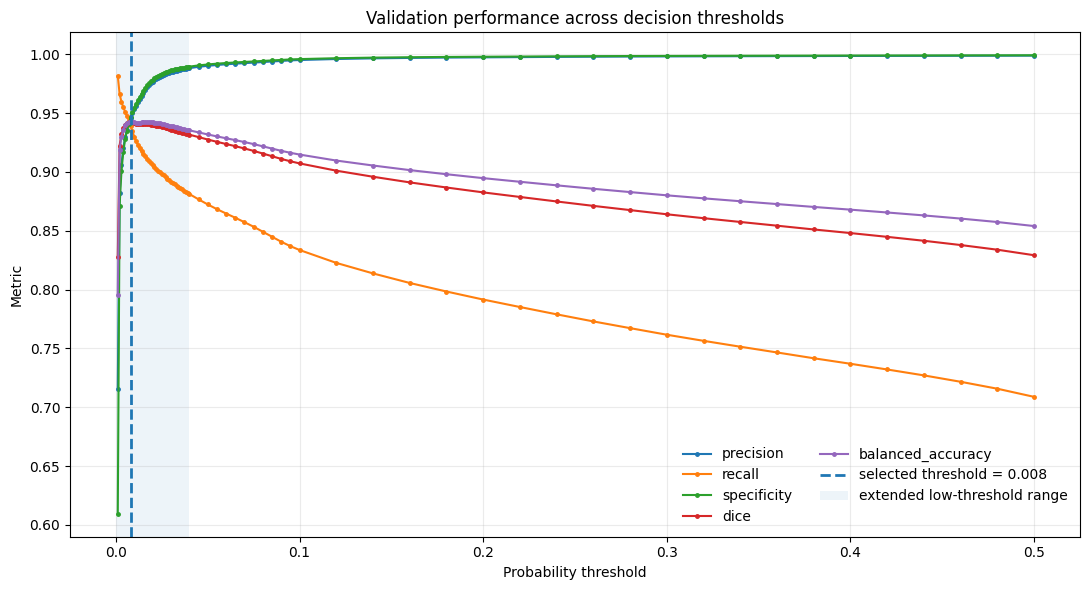

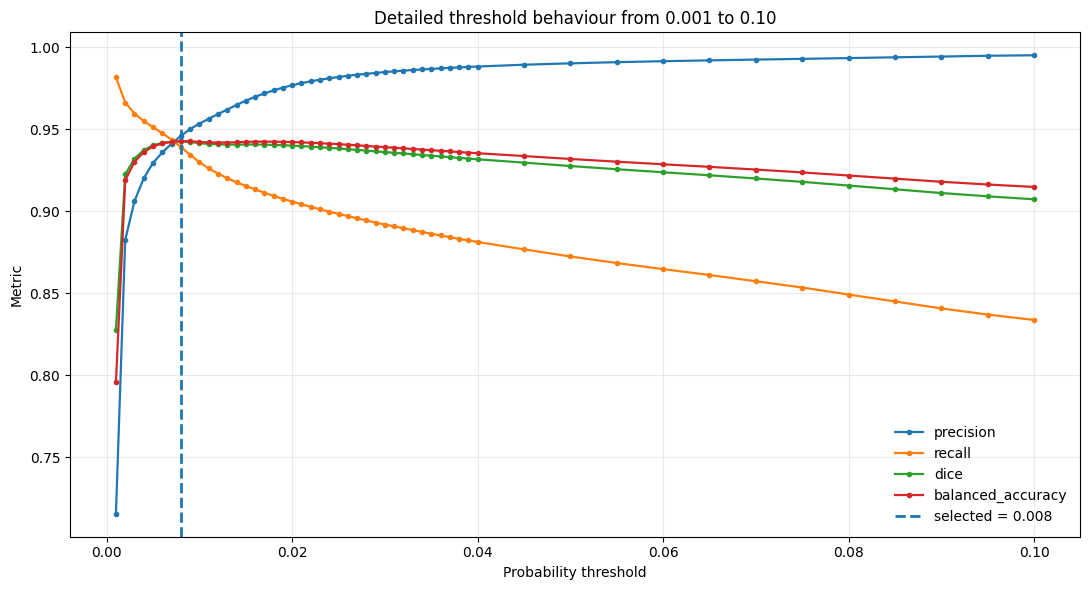


Saved:
/content/drive/MyDrive/Colab Notebooks/Musanga/work/models/classified_tree_threshold_sweep_extended.csv
/content/drive/MyDrive/Colab Notebooks/Musanga/work/models/classified_tree_test_metrics_extended.csv
/content/drive/MyDrive/Colab Notebooks/Musanga/work/models/classified_tree_evaluation_summary_extended.json
/content/drive/MyDrive/Colab Notebooks/Musanga/work/models/evaluation_figures/threshold_sweep_extended.png
/content/drive/MyDrive/Colab Notebooks/Musanga/work/models/evaluation_figures/threshold_sweep_below_010.png


In [21]:

# ======================================================================================
# BLOCK 21 — EXTENDED LOW-THRESHOLD SWEEP AND FINAL TEST EVALUATION
# ======================================================================================

print("\n" + "=" * 100)
print("BLOCK 21 — EXTENDED LOW-THRESHOLD SWEEP AND FINAL TEST EVALUATION")
print("=" * 100)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
)

required_arrays = [
    "val_probabilities",
    "val_references",
    "test_probabilities",
    "test_references",
]

missing_arrays = [
    name for name in required_arrays
    if name not in globals()
]

if missing_arrays:
    raise RuntimeError(
        "Run Block 20 first. Missing arrays: "
        f"{missing_arrays}"
    )

val_probabilities = np.asarray(
    val_probabilities,
    dtype=np.float32,
)
val_references = np.asarray(
    val_references,
    dtype=np.uint8,
)
test_probabilities = np.asarray(
    test_probabilities,
    dtype=np.float32,
)
test_references = np.asarray(
    test_references,
    dtype=np.uint8,
)

# ----------------------------------------------------------------------
# BALANCED PIXEL SAMPLE FOR CHEAP THRESHOLD SELECTION
# ----------------------------------------------------------------------

MAX_SWEEP_PIXELS = 2_000_000
RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)

positive_indices = np.flatnonzero(
    val_references == 1
)
negative_indices = np.flatnonzero(
    val_references == 0
)

if len(val_references) <= MAX_SWEEP_PIXELS:
    sweep_indices = np.arange(
        len(val_references)
    )
else:
    n_positive = min(
        len(positive_indices),
        MAX_SWEEP_PIXELS // 2,
    )
    n_negative = min(
        len(negative_indices),
        MAX_SWEEP_PIXELS - n_positive,
    )

    sampled_positive = rng.choice(
        positive_indices,
        size=n_positive,
        replace=False,
    )
    sampled_negative = rng.choice(
        negative_indices,
        size=n_negative,
        replace=False,
    )

    sweep_indices = np.concatenate(
        [
            sampled_positive,
            sampled_negative,
        ]
    )
    rng.shuffle(sweep_indices)

sweep_probabilities = val_probabilities[
    sweep_indices
]
sweep_references = val_references[
    sweep_indices
]

print(
    "Full validation pixels:",
    f"{len(val_references):,}",
)
print(
    "Threshold-sweep pixels:",
    f"{len(sweep_references):,}",
)
print(
    "Sweep Musanga fraction:",
    f"{sweep_references.mean():.4f}",
)

# ----------------------------------------------------------------------
# METRICS
# ----------------------------------------------------------------------

def calculate_binary_metrics(
    references,
    probabilities,
    threshold,
):
    predictions = probabilities >= threshold
    positives = references == 1
    negatives = ~positives

    tp = int(np.count_nonzero(
        predictions & positives
    ))
    fp = int(np.count_nonzero(
        predictions & negatives
    ))
    fn = int(np.count_nonzero(
        ~predictions & positives
    ))
    tn = int(np.count_nonzero(
        ~predictions & negatives
    ))

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    specificity = tn / max(tn + fp, 1)
    dice = 2 * tp / max(
        2 * tp + fp + fn,
        1,
    )
    iou = tp / max(
        tp + fp + fn,
        1,
    )
    accuracy = (
        tp + tn
    ) / max(
        len(references),
        1,
    )
    balanced_accuracy = (
        recall + specificity
    ) / 2

    return {
        "threshold": float(threshold),
        "precision": float(precision),
        "recall": float(recall),
        "specificity": float(specificity),
        "dice": float(dice),
        "iou": float(iou),
        "accuracy": float(accuracy),
        "balanced_accuracy": float(
            balanced_accuracy
        ),
        "predicted_positive_fraction": float(
            predictions.mean()
        ),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
    }

# Dense search below 0.04, then progressively coarser search above it.
LOW_THRESHOLDS = np.round(
    np.arange(
        0.001,
        0.0401,
        0.001,
    ),
    3,
)

MID_THRESHOLDS = np.round(
    np.arange(
        0.045,
        0.101,
        0.005,
    ),
    3,
)

HIGH_THRESHOLDS = np.round(
    np.arange(
        0.12,
        0.51,
        0.02,
    ),
    3,
)

THRESHOLDS = np.unique(
    np.concatenate(
        [
            LOW_THRESHOLDS,
            MID_THRESHOLDS,
            HIGH_THRESHOLDS,
            np.array([0.50]),
        ]
    )
)

threshold_results = pd.DataFrame(
    [
        calculate_binary_metrics(
            references=sweep_references,
            probabilities=sweep_probabilities,
            threshold=threshold,
        )
        for threshold in THRESHOLDS
    ]
)

best_validation_row = (
    threshold_results
    .sort_values(
        [
            "dice",
            "balanced_accuracy",
        ],
        ascending=False,
    )
    .iloc[0]
)

BEST_LABELLED_TREE_THRESHOLD = float(
    best_validation_row["threshold"]
)

print(
    "\nBest threshold selected from validation polygons:",
    f"{BEST_LABELLED_TREE_THRESHOLD:.3f}",
)

display(
    threshold_results
    .sort_values(
        [
            "dice",
            "balanced_accuracy",
        ],
        ascending=False,
    )
    .head(20)
    .reset_index(drop=True)
)

# Full validation metrics once at the selected threshold.
full_validation_metrics = (
    calculate_binary_metrics(
        references=val_references,
        probabilities=val_probabilities,
        threshold=BEST_LABELLED_TREE_THRESHOLD,
    )
)

# Final held-out test metrics.
default_test_metrics = (
    calculate_binary_metrics(
        references=test_references,
        probabilities=test_probabilities,
        threshold=0.50,
    )
)

selected_test_metrics = (
    calculate_binary_metrics(
        references=test_references,
        probabilities=test_probabilities,
        threshold=BEST_LABELLED_TREE_THRESHOLD,
    )
)

validation_roc_auc = float(
    roc_auc_score(
        val_references,
        val_probabilities,
    )
)
validation_average_precision = float(
    average_precision_score(
        val_references,
        val_probabilities,
    )
)
test_roc_auc = float(
    roc_auc_score(
        test_references,
        test_probabilities,
    )
)
test_average_precision = float(
    average_precision_score(
        test_references,
        test_probabilities,
    )
)

test_comparison = pd.DataFrame(
    [
        {
            "threshold_source": "default_0.50",
            **default_test_metrics,
            "roc_auc": test_roc_auc,
            "average_precision": (
                test_average_precision
            ),
        },
        {
            "threshold_source": (
                "validation_selected"
            ),
            **selected_test_metrics,
            "roc_auc": test_roc_auc,
            "average_precision": (
                test_average_precision
            ),
        },
    ]
)

print("\nHeld-out test comparison:")
display(
    test_comparison[
        [
            "threshold_source",
            "threshold",
            "precision",
            "recall",
            "specificity",
            "dice",
            "iou",
            "balanced_accuracy",
            "predicted_positive_fraction",
            "roc_auc",
            "average_precision",
        ]
    ]
)

# ----------------------------------------------------------------------
# THRESHOLD FIGURES
# ----------------------------------------------------------------------

FIGURE_DIR = MODEL_DIR / "evaluation_figures"
FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

figure, axis = plt.subplots(
    figsize=(11, 6)
)

for metric_name in [
    "precision",
    "recall",
    "specificity",
    "dice",
    "balanced_accuracy",
]:
    axis.plot(
        threshold_results["threshold"],
        threshold_results[metric_name],
        marker="o",
        markersize=2.5,
        linewidth=1.5,
        label=metric_name,
    )

axis.axvline(
    BEST_LABELLED_TREE_THRESHOLD,
    linestyle="--",
    linewidth=2,
    label=(
        "selected threshold = "
        f"{BEST_LABELLED_TREE_THRESHOLD:.3f}"
    ),
)
axis.axvspan(
    0,
    0.04,
    alpha=0.08,
    label="extended low-threshold range",
)
axis.set_xlabel(
    "Probability threshold"
)
axis.set_ylabel(
    "Metric"
)
axis.set_title(
    "Validation performance across decision thresholds"
)
axis.grid(alpha=0.25)
axis.legend(
    ncol=2,
    frameon=False,
)
figure.tight_layout()

THRESHOLD_FIGURE_PATH = (
    FIGURE_DIR
    / "threshold_sweep_extended.png"
)
figure.savefig(
    THRESHOLD_FIGURE_PATH,
    dpi=250,
    bbox_inches="tight",
)
plt.show()
plt.close(figure)

# A zoomed view below 0.10.
zoom_results = threshold_results[
    threshold_results["threshold"] <= 0.10
]

figure, axis = plt.subplots(
    figsize=(11, 6)
)

for metric_name in [
    "precision",
    "recall",
    "dice",
    "balanced_accuracy",
]:
    axis.plot(
        zoom_results["threshold"],
        zoom_results[metric_name],
        marker="o",
        markersize=3,
        linewidth=1.6,
        label=metric_name,
    )

axis.axvline(
    BEST_LABELLED_TREE_THRESHOLD,
    linestyle="--",
    linewidth=2,
    label=(
        "selected = "
        f"{BEST_LABELLED_TREE_THRESHOLD:.3f}"
    ),
)
axis.set_xlabel(
    "Probability threshold"
)
axis.set_ylabel(
    "Metric"
)
axis.set_title(
    "Detailed threshold behaviour from 0.001 to 0.10"
)
axis.grid(alpha=0.25)
axis.legend(
    frameon=False,
)
figure.tight_layout()

LOW_THRESHOLD_FIGURE_PATH = (
    FIGURE_DIR
    / "threshold_sweep_below_010.png"
)
figure.savefig(
    LOW_THRESHOLD_FIGURE_PATH,
    dpi=250,
    bbox_inches="tight",
)
plt.show()
plt.close(figure)

# ----------------------------------------------------------------------
# SAVE TABLES AND SUMMARY
# ----------------------------------------------------------------------

THRESHOLD_SWEEP_PATH = (
    MODEL_DIR
    / "classified_tree_threshold_sweep_extended.csv"
)
TEST_RESULTS_PATH = (
    MODEL_DIR
    / "classified_tree_test_metrics_extended.csv"
)
SUMMARY_PATH = (
    MODEL_DIR
    / "classified_tree_evaluation_summary_extended.json"
)

threshold_results.to_csv(
    THRESHOLD_SWEEP_PATH,
    index=False,
)
test_comparison.to_csv(
    TEST_RESULTS_PATH,
    index=False,
)

evaluation_summary = {
    "threshold_sweep_pixels": int(
        len(sweep_references)
    ),
    "full_validation_pixels": int(
        len(val_references)
    ),
    "full_test_pixels": int(
        len(test_references)
    ),
    "selected_threshold": float(
        BEST_LABELLED_TREE_THRESHOLD
    ),
    "validation_roc_auc": (
        validation_roc_auc
    ),
    "validation_average_precision": (
        validation_average_precision
    ),
    "test_roc_auc": test_roc_auc,
    "test_average_precision": (
        test_average_precision
    ),
    "full_validation_metrics": (
        full_validation_metrics
    ),
    "default_test_metrics": (
        default_test_metrics
    ),
    "selected_threshold_test_metrics": (
        selected_test_metrics
    ),
}

SUMMARY_PATH.write_text(
    json.dumps(
        evaluation_summary,
        indent=2,
    )
)

print("\nSaved:")
print(THRESHOLD_SWEEP_PATH)
print(TEST_RESULTS_PATH)
print(SUMMARY_PATH)
print(THRESHOLD_FIGURE_PATH)
print(LOW_THRESHOLD_FIGURE_PATH)


## BLOCK 22 — Global Musanga versus other-tree probability distributions


BLOCK 22 — GLOBAL MUSANGA VS OTHER-TREE PROBABILITY DISTRIBUTIONS


,class,n_pixels,mean,median,p01,p05,p25,p75,p95,p99,fraction_above_threshold
0,Musanga,9251646,0.606354,0.751002,0.000714,0.004813,0.256923,0.899771,0.974129,0.989972,0.935333
1,Other trees,11521136,0.003078,0.000781,0.000193,0.000291,0.000539,0.001226,0.007287,0.023840,0.044395


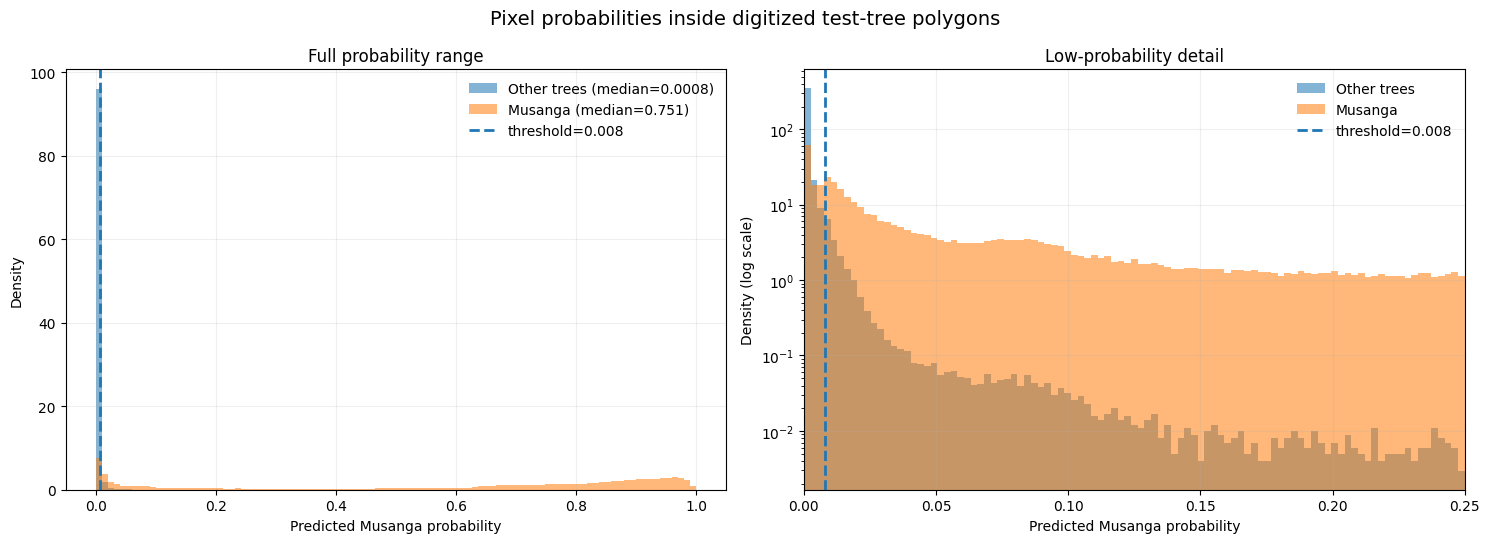


Saved:
/content/drive/MyDrive/Colab Notebooks/Musanga/work/models/evaluation_figures/global_probability_distributions.png
/content/drive/MyDrive/Colab Notebooks/Musanga/work/models/global_test_probability_summary.csv


In [22]:

# ======================================================================================
# BLOCK 22 — GLOBAL MUSANGA VS OTHER-TREE PROBABILITY DISTRIBUTIONS
# ======================================================================================

print("\n" + "=" * 100)
print("BLOCK 22 — GLOBAL MUSANGA VS OTHER-TREE PROBABILITY DISTRIBUTIONS")
print("=" * 100)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "BEST_LABELLED_TREE_THRESHOLD" not in globals():
    raise RuntimeError(
        "Run Block 21 first."
    )

musanga_probabilities = test_probabilities[
    test_references == 1
]
other_probabilities = test_probabilities[
    test_references == 0
]

def probability_summary(
    name,
    values,
):
    return {
        "class": name,
        "n_pixels": int(len(values)),
        "mean": float(np.mean(values)),
        "median": float(np.median(values)),
        "p01": float(np.percentile(values, 1)),
        "p05": float(np.percentile(values, 5)),
        "p25": float(np.percentile(values, 25)),
        "p75": float(np.percentile(values, 75)),
        "p95": float(np.percentile(values, 95)),
        "p99": float(np.percentile(values, 99)),
        "fraction_above_threshold": float(
            np.mean(
                values
                >= BEST_LABELLED_TREE_THRESHOLD
            )
        ),
    }

global_probability_summary = pd.DataFrame(
    [
        probability_summary(
            "Musanga",
            musanga_probabilities,
        ),
        probability_summary(
            "Other trees",
            other_probabilities,
        ),
    ]
)

display(global_probability_summary)

# Sample for plotting only; all metrics above use every pixel.
rng = np.random.default_rng(42)
MAX_PLOT_PIXELS_PER_CLASS = 400_000

def plot_sample(values):
    if len(values) <= MAX_PLOT_PIXELS_PER_CLASS:
        return values
    indices = rng.choice(
        len(values),
        size=MAX_PLOT_PIXELS_PER_CLASS,
        replace=False,
    )
    return values[indices]

musanga_plot = plot_sample(
    musanga_probabilities
)
other_plot = plot_sample(
    other_probabilities
)

figure, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5.5),
)

# Full probability range.
bins_full = np.linspace(
    0,
    1,
    100,
)

axes[0].hist(
    other_plot,
    bins=bins_full,
    density=True,
    alpha=0.55,
    label=(
        "Other trees "
        f"(median={np.median(other_probabilities):.4f})"
    ),
)
axes[0].hist(
    musanga_plot,
    bins=bins_full,
    density=True,
    alpha=0.55,
    label=(
        "Musanga "
        f"(median={np.median(musanga_probabilities):.3f})"
    ),
)
axes[0].axvline(
    BEST_LABELLED_TREE_THRESHOLD,
    linestyle="--",
    linewidth=2,
    label=(
        "threshold="
        f"{BEST_LABELLED_TREE_THRESHOLD:.3f}"
    ),
)
axes[0].set_xlabel(
    "Predicted Musanga probability"
)
axes[0].set_ylabel(
    "Density"
)
axes[0].set_title(
    "Full probability range"
)
axes[0].grid(alpha=0.2)
axes[0].legend(
    frameon=False,
)

# Low-probability range, displayed on a log y-axis.
LOW_RANGE_MAX = max(
    0.10,
    min(
        0.25,
        float(
            np.percentile(
                musanga_plot,
                30,
            )
        ),
    ),
)
bins_low = np.linspace(
    0,
    LOW_RANGE_MAX,
    100,
)

axes[1].hist(
    other_plot,
    bins=bins_low,
    density=True,
    alpha=0.55,
    label="Other trees",
)
axes[1].hist(
    musanga_plot,
    bins=bins_low,
    density=True,
    alpha=0.55,
    label="Musanga",
)
axes[1].axvline(
    BEST_LABELLED_TREE_THRESHOLD,
    linestyle="--",
    linewidth=2,
    label=(
        "threshold="
        f"{BEST_LABELLED_TREE_THRESHOLD:.3f}"
    ),
)
axes[1].set_yscale("log")
axes[1].set_xlim(
    0,
    LOW_RANGE_MAX,
)
axes[1].set_xlabel(
    "Predicted Musanga probability"
)
axes[1].set_ylabel(
    "Density (log scale)"
)
axes[1].set_title(
    "Low-probability detail"
)
axes[1].grid(alpha=0.2)
axes[1].legend(
    frameon=False,
)

figure.suptitle(
    "Pixel probabilities inside digitized test-tree polygons",
    fontsize=14,
)
figure.tight_layout()

GLOBAL_HISTOGRAM_PATH = (
    FIGURE_DIR
    / "global_probability_distributions.png"
)
figure.savefig(
    GLOBAL_HISTOGRAM_PATH,
    dpi=250,
    bbox_inches="tight",
)
plt.show()
plt.close(figure)

GLOBAL_PROBABILITY_SUMMARY_PATH = (
    MODEL_DIR
    / "global_test_probability_summary.csv"
)
global_probability_summary.to_csv(
    GLOBAL_PROBABILITY_SUMMARY_PATH,
    index=False,
)

print("\nSaved:")
print(GLOBAL_HISTOGRAM_PATH)
print(GLOBAL_PROBABILITY_SUMMARY_PATH)


## BLOCK 23 — Publication-style observed-versus-model maps

In [23]:

# ======================================================================================
# BLOCK 23 — PUBLICATION-STYLE OBSERVED-VERSUS-MODEL MAPS
# ======================================================================================

print("\n" + "=" * 100)
print("BLOCK 23 — PUBLICATION-STYLE OBSERVED-VERSUS-MODEL MAPS")
print("=" * 100)

import numpy as np
import matplotlib.pyplot as plt
import rasterio
import torch

from matplotlib.colors import ListedColormap
from rasterio.features import rasterize
from rasterio.windows import Window
from shapely.geometry import box

N_EXAMPLES = 6
MIN_MUSANGA_POLYGONS = 1
MIN_OTHER_POLYGONS = 1
MAX_BATCHES_TO_SCAN = 40

DISPLAY_THRESHOLD = float(
    BEST_LABELLED_TREE_THRESHOLD
)

patch_lookup = (
    full_patch_index[
        [
            "patch_id",
            "row_off",
            "col_off",
            "height",
            "width",
            "split",
        ]
    ]
    .drop_duplicates("patch_id")
    .set_index("patch_id")
)

def display_rgb(image_tensor):
    rgb = (
        image_tensor[:3]
        .detach()
        .cpu()
        .numpy()
    )
    rgb = np.moveaxis(
        rgb,
        0,
        -1,
    ).astype(np.float32)

    for channel_index in range(3):
        channel = rgb[..., channel_index]
        lower = np.nanpercentile(
            channel,
            2,
        )
        upper = np.nanpercentile(
            channel,
            98,
        )
        if upper > lower:
            rgb[..., channel_index] = (
                channel - lower
            ) / (
                upper - lower
            )
        else:
            rgb[..., channel_index] = 0

    return np.clip(
        rgb,
        0,
        1,
    )

examples = []
model.eval()

with rasterio.open(
    LOCAL_RASTER_PATH
) as raster_src, torch.inference_mode():

    for batch_index, batch in enumerate(
        test_loader
    ):
        images = batch["image"].to(
            DEVICE,
            non_blocking=True,
        )
        probabilities = (
            torch.sigmoid(
                model(images)
            )
            .detach()
            .cpu()
            .numpy()[:, 0]
        )

        for row, patch_id_value in enumerate(
            batch["patch_id"]
        ):
            patch_id = str(
                patch_id_value
            )

            if patch_id not in patch_lookup.index:
                continue

            record = patch_lookup.loc[
                patch_id
            ]

            height = int(
                record["height"]
            )
            width = int(
                record["width"]
            )

            window = Window(
                col_off=int(record["col_off"]),
                row_off=int(record["row_off"]),
                width=width,
                height=height,
            )
            transform = raster_src.window_transform(
                window
            )
            bounds = rasterio.windows.bounds(
                window,
                raster_src.transform,
            )
            patch_geometry = box(*bounds)

            candidate_indices = list(
                trees.sindex.intersection(
                    patch_geometry.bounds
                )
            )
            if not candidate_indices:
                continue

            patch_trees = trees.iloc[
                candidate_indices
            ].copy()
            patch_trees = patch_trees[
                patch_trees.intersects(
                    patch_geometry
                )
            ].copy()

            n_musanga = int(
                (
                    patch_trees[
                        "reference_class"
                    ] == 1
                ).sum()
            )
            n_other = int(
                (
                    patch_trees[
                        "reference_class"
                    ] == 0
                ).sum()
            )

            if (
                n_musanga < MIN_MUSANGA_POLYGONS
                or n_other < MIN_OTHER_POLYGONS
            ):
                continue

            labelled_mask = rasterize(
                [
                    (geometry, 1)
                    for geometry
                    in patch_trees.geometry
                    if geometry is not None
                    and not geometry.is_empty
                ],
                out_shape=(height, width),
                transform=transform,
                fill=0,
                dtype=np.uint8,
            ).astype(bool)

            musanga_trees = patch_trees[
                patch_trees[
                    "reference_class"
                ] == 1
            ]

            musanga_mask = rasterize(
                [
                    (geometry, 1)
                    for geometry
                    in musanga_trees.geometry
                    if geometry is not None
                    and not geometry.is_empty
                ],
                out_shape=(height, width),
                transform=transform,
                fill=0,
                dtype=np.uint8,
            ).astype(bool)

            valid_mask = (
                batch["valid_mask"][
                    row,
                    0,
                    :height,
                    :width,
                ]
                .detach()
                .cpu()
                .numpy()
                >= 0.5
            )

            evaluation_mask = (
                labelled_mask
                & valid_mask
            )

            if not evaluation_mask.any():
                continue

            probability = probabilities[
                row,
                :height,
                :width,
            ]
            prediction = (
                probability
                >= DISPLAY_THRESHOLD
            )

            truth = musanga_mask
            tp = int(
                (
                    prediction
                    & truth
                    & evaluation_mask
                ).sum()
            )
            fp = int(
                (
                    prediction
                    & ~truth
                    & evaluation_mask
                ).sum()
            )
            fn = int(
                (
                    ~prediction
                    & truth
                    & evaluation_mask
                ).sum()
            )

            dice = (
                2 * tp
                / max(
                    2 * tp + fp + fn,
                    1,
                )
            )

            examples.append(
                {
                    "patch_id": patch_id,
                    "image": batch[
                        "image"
                    ][row],
                    "height": height,
                    "width": width,
                    "evaluation_mask": (
                        evaluation_mask
                    ),
                    "truth": truth,
                    "probability": probability,
                    "prediction": prediction,
                    "n_musanga": n_musanga,
                    "n_other": n_other,
                    "dice": dice,
                }
            )

        if (
            len(examples) >= N_EXAMPLES * 5
            or batch_index + 1
            >= MAX_BATCHES_TO_SCAN
        ):
            break

if not examples:
    raise RuntimeError(
        "No suitable test examples were found."
    )

# Select cases across the observed performance range.
examples = sorted(
    examples,
    key=lambda item: item["dice"],
)

indices = np.linspace(
    0,
    len(examples) - 1,
    min(N_EXAMPLES, len(examples)),
).round().astype(int)

selected_examples = [
    examples[index]
    for index in indices
]

observation_cmap = ListedColormap(
    [
        "white",
        "#7f7f7f",
        "#ffd92f",
    ]
)
error_cmap = ListedColormap(
    [
        "white",
        "#dddddd",
        "#4daf4a",
        "#e41a1c",
        "#377eb8",
    ]
)

for example_number, example in enumerate(
    selected_examples,
    start=1,
):
    height = example["height"]
    width = example["width"]
    evaluation_mask = example[
        "evaluation_mask"
    ]
    truth = example["truth"]
    probability = example[
        "probability"
    ]
    prediction = example[
        "prediction"
    ]

    rgb = display_rgb(
        example["image"]
    )[
        :height,
        :width,
    ].copy()

    observed = np.zeros(
        (height, width),
        dtype=np.uint8,
    )
    observed[
        evaluation_mask & ~truth
    ] = 1
    observed[
        evaluation_mask & truth
    ] = 2

    overlay = rgb.copy()
    overlay[
        evaluation_mask & truth
    ] = (
        0.55
        * overlay[
            evaluation_mask & truth
        ]
        + 0.45
        * np.array(
            [1.0, 0.75, 0.0]
        )
    )
    overlay[
        evaluation_mask & ~truth
    ] = (
        0.65
        * overlay[
            evaluation_mask & ~truth
        ]
        + 0.35
        * np.array(
            [0.1, 0.6, 0.9]
        )
    )

    error_map = np.zeros(
        (height, width),
        dtype=np.uint8,
    )
    error_map[
        evaluation_mask
        & ~truth
        & ~prediction
    ] = 1
    error_map[
        evaluation_mask
        & truth
        & prediction
    ] = 2
    error_map[
        evaluation_mask
        & ~truth
        & prediction
    ] = 3
    error_map[
        evaluation_mask
        & truth
        & ~prediction
    ] = 4

    figure, axes = plt.subplots(
        2,
        3,
        figsize=(15, 9),
    )

    axes[0, 0].imshow(rgb)
    axes[0, 0].set_title(
        "RGB orthomosaic patch"
    )

    axes[0, 1].imshow(overlay)
    axes[0, 1].set_title(
        "Observed polygon overlay\n"
        "yellow = Musanga; blue = other"
    )

    axes[0, 2].imshow(
        observed,
        cmap=observation_cmap,
        vmin=0,
        vmax=2,
    )
    axes[0, 2].set_title(
        "Observed classes"
    )

    probability_image = axes[1, 0].imshow(
        np.where(
            evaluation_mask,
            probability,
            np.nan,
        ),
        cmap="magma",
        vmin=0,
        vmax=1,
    )
    axes[1, 0].set_title(
        "Model probability (0–1)"
    )
    figure.colorbar(
        probability_image,
        ax=axes[1, 0],
        fraction=0.046,
        pad=0.04,
    )

    low_probability_image = axes[
        1,
        1,
    ].imshow(
        np.where(
            evaluation_mask,
            probability,
            np.nan,
        ),
        cmap="magma",
        vmin=0,
        vmax=max(
            0.10,
            DISPLAY_THRESHOLD * 3,
        ),
    )
    axes[1, 1].set_title(
        "Low-probability detail\n"
        f"threshold={DISPLAY_THRESHOLD:.3f}"
    )
    figure.colorbar(
        low_probability_image,
        ax=axes[1, 1],
        fraction=0.046,
        pad=0.04,
    )

    axes[1, 2].imshow(
        error_map,
        cmap=error_cmap,
        vmin=0,
        vmax=4,
    )
    axes[1, 2].set_title(
        "Agreement map\n"
        "green=TP; red=FP; blue=FN"
    )

    for axis in axes.ravel():
        axis.axis("off")

    figure.suptitle(
        (
            f"Test patch {example['patch_id']} — "
            f"{example['n_musanga']} Musanga / "
            f"{example['n_other']} other polygons — "
            f"pixel Dice={example['dice']:.3f}"
        ),
        fontsize=13,
    )
    figure.tight_layout()

    output_path = (
        FIGURE_DIR
        / (
            f"observed_vs_probability_"
            f"{example_number:02d}.png"
        )
    )
    figure.savefig(
        output_path,
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(figure)

print(
    f"Saved {len(selected_examples)} example figures to:"
)
print(FIGURE_DIR)


Output hidden; open in https://colab.research.google.com to view.

## BLOCK 24 — Compact probability histograms for the displayed patches


BLOCK 24 — PATCH-LEVEL POSITIVE VS NEGATIVE PROBABILITY HISTOGRAMS


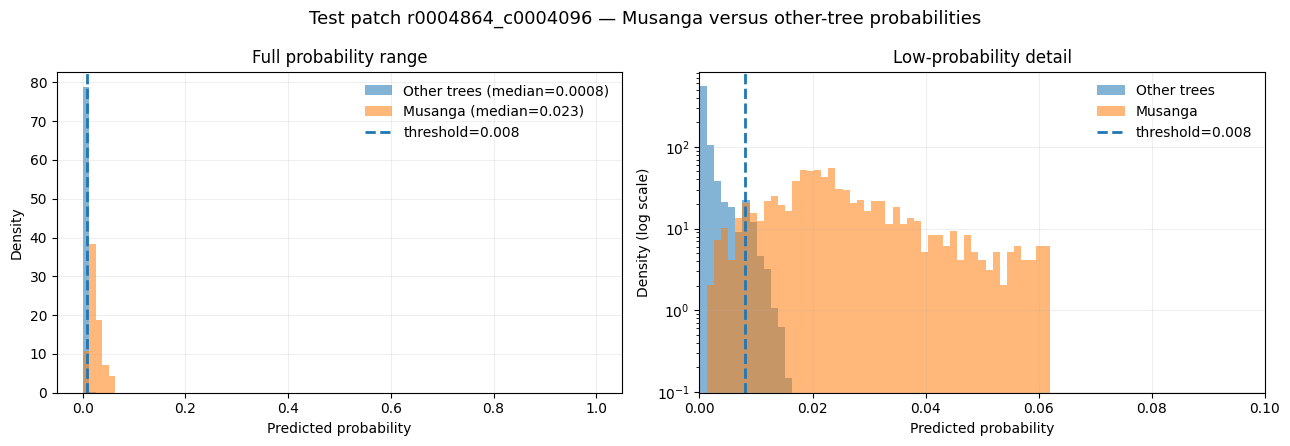

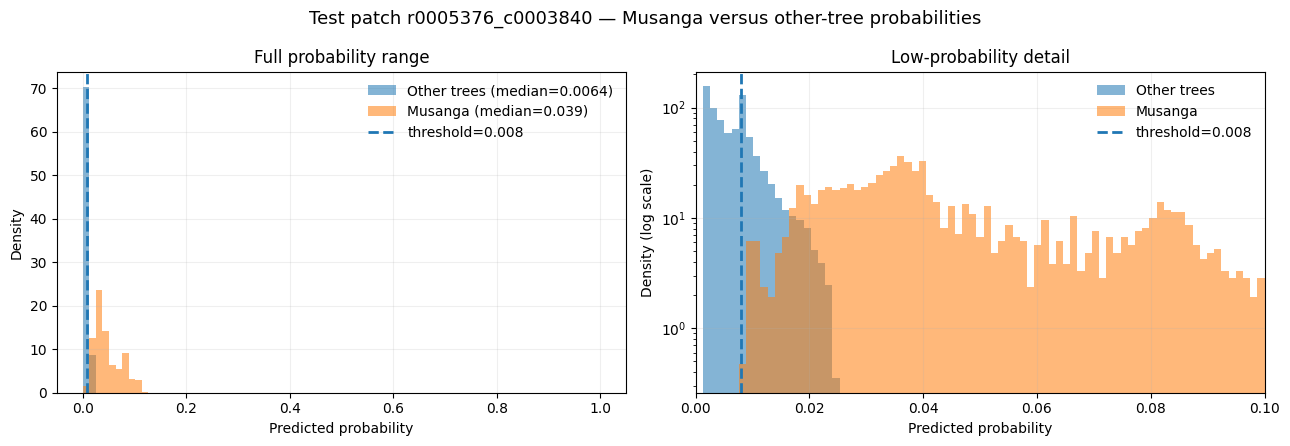

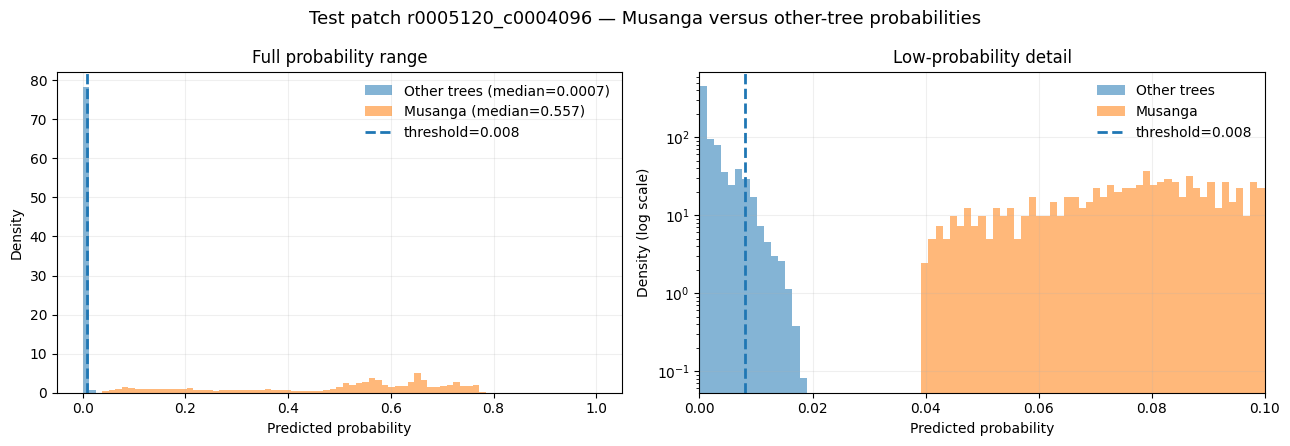

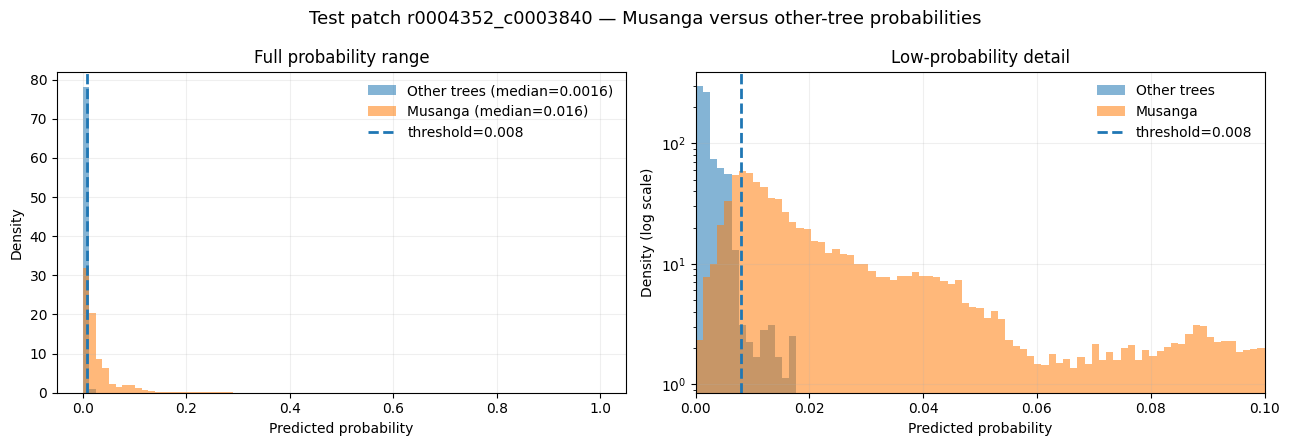

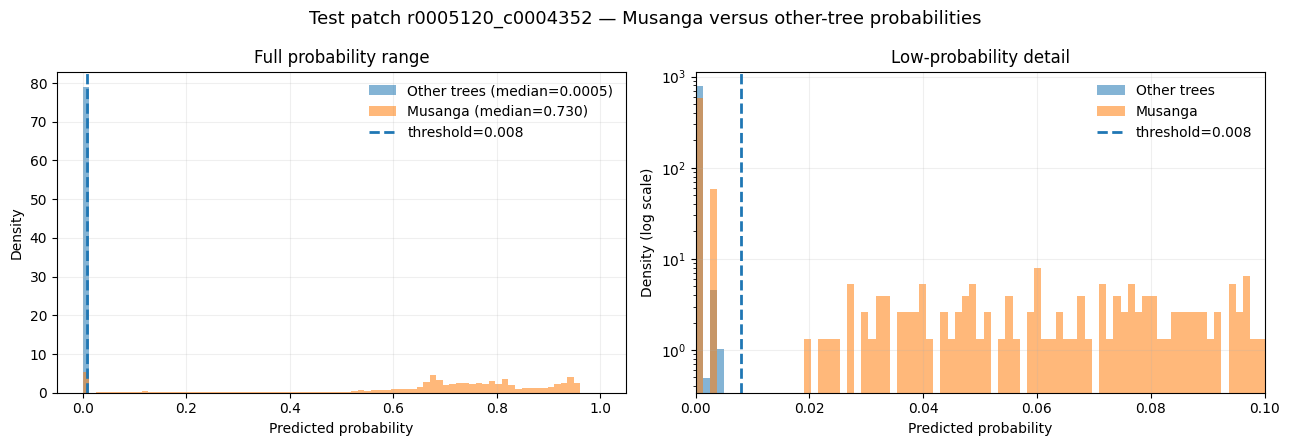

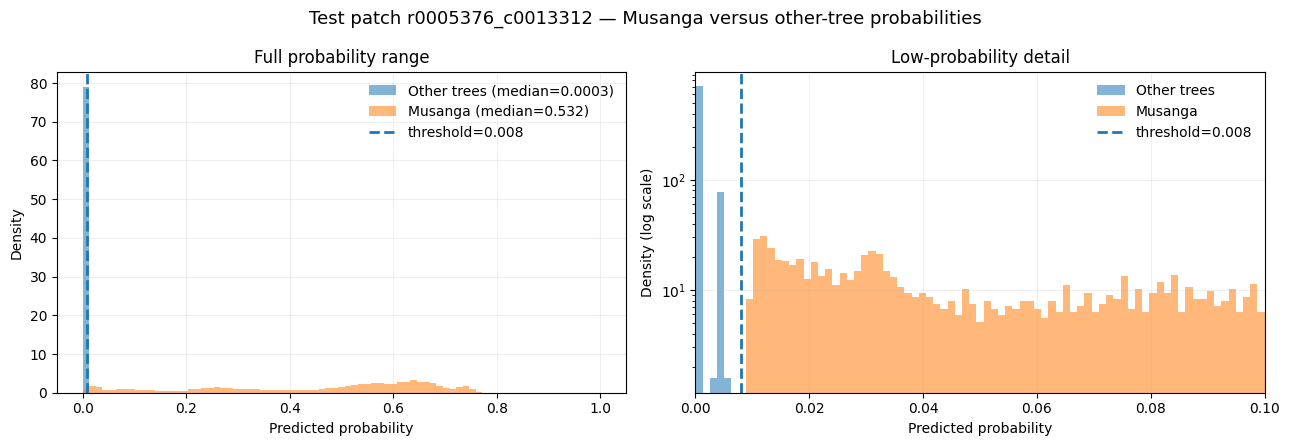

Saved patch-level probability histograms to:
/content/drive/MyDrive/Colab Notebooks/Musanga/work/models/evaluation_figures


In [24]:

# ======================================================================================
# BLOCK 24 — PATCH-LEVEL POSITIVE VS NEGATIVE PROBABILITY HISTOGRAMS
# ======================================================================================

print("\n" + "=" * 100)
print("BLOCK 24 — PATCH-LEVEL POSITIVE VS NEGATIVE PROBABILITY HISTOGRAMS")
print("=" * 100)

for example_number, example in enumerate(
    selected_examples,
    start=1,
):
    evaluation_mask = example[
        "evaluation_mask"
    ]
    truth = example["truth"]
    probability = example[
        "probability"
    ]

    positive_values = probability[
        evaluation_mask & truth
    ]
    negative_values = probability[
        evaluation_mask & ~truth
    ]

    if (
        len(positive_values) == 0
        or len(negative_values) == 0
    ):
        continue

    figure, axes = plt.subplots(
        1,
        2,
        figsize=(13, 4.5),
    )

    bins_full = np.linspace(
        0,
        1,
        80,
    )
    axes[0].hist(
        negative_values,
        bins=bins_full,
        density=True,
        alpha=0.55,
        label=(
            "Other trees "
            f"(median={np.median(negative_values):.4f})"
        ),
    )
    axes[0].hist(
        positive_values,
        bins=bins_full,
        density=True,
        alpha=0.55,
        label=(
            "Musanga "
            f"(median={np.median(positive_values):.3f})"
        ),
    )
    axes[0].axvline(
        DISPLAY_THRESHOLD,
        linestyle="--",
        linewidth=2,
        label=(
            "threshold="
            f"{DISPLAY_THRESHOLD:.3f}"
        ),
    )
    axes[0].set_xlabel(
        "Predicted probability"
    )
    axes[0].set_ylabel(
        "Density"
    )
    axes[0].set_title(
        "Full probability range"
    )
    axes[0].grid(alpha=0.2)
    axes[0].legend(
        frameon=False,
    )

    low_max = max(
        0.10,
        DISPLAY_THRESHOLD * 3,
    )
    bins_low = np.linspace(
        0,
        low_max,
        80,
    )
    axes[1].hist(
        negative_values,
        bins=bins_low,
        density=True,
        alpha=0.55,
        label="Other trees",
    )
    axes[1].hist(
        positive_values,
        bins=bins_low,
        density=True,
        alpha=0.55,
        label="Musanga",
    )
    axes[1].axvline(
        DISPLAY_THRESHOLD,
        linestyle="--",
        linewidth=2,
        label=(
            "threshold="
            f"{DISPLAY_THRESHOLD:.3f}"
        ),
    )
    axes[1].set_yscale("log")
    axes[1].set_xlim(
        0,
        low_max,
    )
    axes[1].set_xlabel(
        "Predicted probability"
    )
    axes[1].set_ylabel(
        "Density (log scale)"
    )
    axes[1].set_title(
        "Low-probability detail"
    )
    axes[1].grid(alpha=0.2)
    axes[1].legend(
        frameon=False,
    )

    figure.suptitle(
        (
            f"Test patch {example['patch_id']} — "
            "Musanga versus other-tree probabilities"
        ),
        fontsize=13,
    )
    figure.tight_layout()

    output_path = (
        FIGURE_DIR
        / (
            f"patch_probability_histogram_"
            f"{example_number:02d}.png"
        )
    )
    figure.savefig(
        output_path,
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(figure)

print(
    "Saved patch-level probability histograms to:"
)
print(FIGURE_DIR)


## BLOCK 25 — Polygon-level evaluation

Each unique digitized crown is counted once. The model probability is aggregated across all valid pixels belonging to that polygon, including portions occurring in more than one image patch. The polygon decision threshold is selected only from validation polygons and then applied unchanged to held-out test polygons.

In [25]:

# ======================================================================================
# BLOCK 25 — POLYGON-LEVEL EVALUATION
# ======================================================================================

print("\n" + "=" * 100)
print("BLOCK 25 — POLYGON-LEVEL EVALUATION")
print("=" * 100)

import json
import numpy as np
import pandas as pd
import rasterio
import torch

from rasterio.features import rasterize
from rasterio.windows import Window
from shapely.geometry import box
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    roc_auc_score,
)
from tqdm.auto import tqdm


# ----------------------------------------------------------------------
# CONFIGURATION
# ----------------------------------------------------------------------

# Each polygon receives one score. Mean probability is the primary score.
POLYGON_SCORE_COLUMN = "mean_probability"

# Polygons with fewer valid pixels than this are omitted.
MIN_VALID_PIXELS_PER_POLYGON = 20

# Dense search in the low-probability range, where the pixel threshold lies,
# followed by a coarser search across the rest of the probability range.
POLYGON_THRESHOLDS = np.unique(
    np.concatenate(
        [
            np.arange(0.001, 0.0401, 0.001),
            np.arange(0.045, 0.101, 0.005),
            np.arange(0.12, 0.51, 0.02),
            np.arange(0.55, 1.00, 0.05),
        ]
    )
).round(3)


# ----------------------------------------------------------------------
# CHECK REQUIRED OBJECTS
# ----------------------------------------------------------------------

required_objects = [
    "model",
    "validation_loader",
    "test_loader",
    "full_patch_index",
    "trees",
    "LOCAL_RASTER_PATH",
    "DEVICE",
    "MODEL_DIR",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Run the preceding setup, model-reload, shapefile, and DataLoader blocks first.\n"
        f"Missing objects: {missing_objects}"
    )

required_tree_columns = {
    "tree_id",
    "Clss_ID",
    "reference_class",
    "geometry",
}

missing_tree_columns = (
    required_tree_columns
    - set(trees.columns)
)

if missing_tree_columns:
    raise ValueError(
        "The classified-tree table lacks required columns:\n"
        f"{sorted(missing_tree_columns)}"
    )


# ----------------------------------------------------------------------
# SPATIAL PATCH LOOKUP
# ----------------------------------------------------------------------

patch_lookup = (
    full_patch_index[
        [
            "patch_id",
            "split",
            "row_off",
            "col_off",
            "height",
            "width",
        ]
    ]
    .drop_duplicates(
        subset="patch_id",
        keep="first",
    )
    .set_index("patch_id")
)


# ----------------------------------------------------------------------
# COLLECT ONE AGGREGATED SCORE PER UNIQUE POLYGON
# ----------------------------------------------------------------------

def collect_polygon_scores(
    loader,
    split_name,
):
    """
    Aggregate predictions for each unique digitized tree polygon.

    A polygon crossing multiple patches is combined into one polygon record.
    Duplicate coverage from overlapping patches is averaged through the
    accumulated pixel sums and counts.
    """

    accumulators = {}

    model.eval()

    with rasterio.open(
        LOCAL_RASTER_PATH
    ) as raster_src, torch.inference_mode():

        for batch in tqdm(
            loader,
            desc=f"{split_name}: polygon-level inference",
        ):

            images = batch["image"].to(
                DEVICE,
                non_blocking=True,
            )

            logits = model(images)

            if isinstance(logits, dict):
                logits = logits.get(
                    "out",
                    logits.get("logits"),
                )

            if hasattr(logits, "logits"):
                logits = logits.logits

            probabilities = (
                torch.sigmoid(logits)
                .detach()
                .cpu()
                .numpy()[:, 0]
            )

            patch_ids = [
                str(value)
                for value in batch["patch_id"]
            ]

            for batch_row, patch_id in enumerate(
                patch_ids
            ):

                if patch_id not in patch_lookup.index:
                    raise KeyError(
                        f"Patch {patch_id!r} is absent from full_patch_index."
                    )

                record = patch_lookup.loc[
                    patch_id
                ]

                row_off = int(record["row_off"])
                col_off = int(record["col_off"])
                height = int(record["height"])
                width = int(record["width"])

                window = Window(
                    col_off=col_off,
                    row_off=row_off,
                    width=width,
                    height=height,
                )

                window_transform = (
                    raster_src.window_transform(
                        window
                    )
                )

                xmin, ymin, xmax, ymax = (
                    rasterio.windows.bounds(
                        window,
                        raster_src.transform,
                    )
                )

                patch_geometry = box(
                    xmin,
                    ymin,
                    xmax,
                    ymax,
                )

                candidate_indices = list(
                    trees.sindex.intersection(
                        patch_geometry.bounds
                    )
                )

                if not candidate_indices:
                    continue

                patch_trees = trees.iloc[
                    candidate_indices
                ].copy()

                patch_trees = patch_trees[
                    patch_trees.intersects(
                        patch_geometry
                    )
                ].copy()

                if patch_trees.empty:
                    continue

                valid_mask = (
                    batch["valid_mask"][
                        batch_row,
                        0,
                        :height,
                        :width,
                    ]
                    .detach()
                    .cpu()
                    .numpy()
                    >= 0.5
                )

                patch_probability = probabilities[
                    batch_row,
                    :height,
                    :width,
                ]

                for tree_record in patch_trees.itertuples(
                    index=False
                ):

                    tree_id = int(
                        tree_record.tree_id
                    )
                    geometry = tree_record.geometry

                    if (
                        geometry is None
                        or geometry.is_empty
                    ):
                        continue

                    polygon_mask = rasterize(
                        [
                            (
                                geometry,
                                1,
                            )
                        ],
                        out_shape=(
                            height,
                            width,
                        ),
                        transform=window_transform,
                        fill=0,
                        dtype=np.uint8,
                        all_touched=False,
                    ).astype(bool)

                    evaluation_mask = (
                        polygon_mask
                        & valid_mask
                    )

                    n_pixels = int(
                        evaluation_mask.sum()
                    )

                    if n_pixels == 0:
                        continue

                    values = patch_probability[
                        evaluation_mask
                    ].astype(np.float64)

                    if tree_id not in accumulators:
                        accumulators[tree_id] = {
                            "tree_id": tree_id,
                            "split": split_name,
                            "Clss_ID": tree_record.Clss_ID,
                            "reference": int(
                                tree_record.reference_class
                            ),
                            "probability_sum": 0.0,
                            "probability_max": 0.0,
                            "n_valid_pixels": 0,
                            "n_patch_intersections": 0,
                        }

                    accumulator = accumulators[
                        tree_id
                    ]

                    accumulator[
                        "probability_sum"
                    ] += float(
                        values.sum()
                    )

                    accumulator[
                        "probability_max"
                    ] = max(
                        accumulator[
                            "probability_max"
                        ],
                        float(
                            values.max()
                        ),
                    )

                    accumulator[
                        "n_valid_pixels"
                    ] += n_pixels

                    accumulator[
                        "n_patch_intersections"
                    ] += 1

    rows = []

    for accumulator in accumulators.values():

        n_valid_pixels = int(
            accumulator["n_valid_pixels"]
        )

        if (
            n_valid_pixels
            < MIN_VALID_PIXELS_PER_POLYGON
        ):
            continue

        rows.append(
            {
                "tree_id": accumulator["tree_id"],
                "split": accumulator["split"],
                "Clss_ID": accumulator["Clss_ID"],
                "reference": accumulator["reference"],
                "mean_probability": (
                    accumulator[
                        "probability_sum"
                    ]
                    / n_valid_pixels
                ),
                "maximum_probability": accumulator[
                    "probability_max"
                ],
                "n_valid_pixels": n_valid_pixels,
                "n_patch_intersections": accumulator[
                    "n_patch_intersections"
                ],
            }
        )

    result = pd.DataFrame(rows)

    if result.empty:
        raise RuntimeError(
            f"No usable polygons were collected for {split_name}."
        )

    print(
        f"\n{split_name.capitalize()} polygons:"
    )
    print(
        "  Total:",
        f"{len(result):,}",
    )
    print(
        "  Musanga:",
        f"{int(result['reference'].sum()):,}",
    )
    print(
        "  Other trees:",
        f"{int((result['reference'] == 0).sum()):,}",
    )
    print(
        "  Median valid pixels/polygon:",
        f"{result['n_valid_pixels'].median():.0f}",
    )

    return result


validation_polygon_scores = (
    collect_polygon_scores(
        loader=validation_loader,
        split_name="validation",
    )
)

test_polygon_scores = (
    collect_polygon_scores(
        loader=test_loader,
        split_name="test",
    )
)


# ----------------------------------------------------------------------
# REMOVE POLYGONS THAT APPEAR IN BOTH SPLITS
# ----------------------------------------------------------------------

shared_tree_ids = set(
    validation_polygon_scores["tree_id"]
).intersection(
    set(test_polygon_scores["tree_id"])
)

print(
    "\nUnique polygons present in both validation and test:",
    len(shared_tree_ids),
)

if shared_tree_ids:

    validation_polygon_scores = (
        validation_polygon_scores[
            ~validation_polygon_scores[
                "tree_id"
            ].isin(shared_tree_ids)
        ]
        .copy()
        .reset_index(drop=True)
    )

    test_polygon_scores = (
        test_polygon_scores[
            ~test_polygon_scores[
                "tree_id"
            ].isin(shared_tree_ids)
        ]
        .copy()
        .reset_index(drop=True)
    )

    print(
        "Shared polygons were excluded from both sets."
    )


# ----------------------------------------------------------------------
# POLYGON METRIC FUNCTION
# ----------------------------------------------------------------------

def calculate_polygon_metrics(
    references,
    scores,
    threshold,
):
    predictions = (
        scores >= threshold
    ).astype(np.uint8)

    tn, fp, fn, tp = confusion_matrix(
        references,
        predictions,
        labels=[0, 1],
    ).ravel()

    precision = (
        tp / max(tp + fp, 1)
    )
    recall = (
        tp / max(tp + fn, 1)
    )
    specificity = (
        tn / max(tn + fp, 1)
    )
    f1 = (
        2 * tp
        / max(
            2 * tp + fp + fn,
            1,
        )
    )
    iou = (
        tp
        / max(
            tp + fp + fn,
            1,
        )
    )
    accuracy = (
        tp + tn
    ) / max(
        tp + tn + fp + fn,
        1,
    )
    balanced_accuracy = (
        recall + specificity
    ) / 2

    return {
        "threshold": float(threshold),
        "precision": float(precision),
        "recall": float(recall),
        "specificity": float(specificity),
        "f1_dice": float(f1),
        "iou": float(iou),
        "accuracy": float(accuracy),
        "balanced_accuracy": float(
            balanced_accuracy
        ),
        "predicted_positive_fraction": float(
            predictions.mean()
        ),
        "true_positive": int(tp),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_negative": int(tn),
    }


# ----------------------------------------------------------------------
# SELECT POLYGON THRESHOLD USING VALIDATION POLYGONS ONLY
# ----------------------------------------------------------------------

validation_polygon_references = (
    validation_polygon_scores[
        "reference"
    ].to_numpy(dtype=np.uint8)
)

validation_polygon_probabilities = (
    validation_polygon_scores[
        POLYGON_SCORE_COLUMN
    ].to_numpy(dtype=np.float32)
)

polygon_threshold_results = pd.DataFrame(
    [
        calculate_polygon_metrics(
            references=(
                validation_polygon_references
            ),
            scores=(
                validation_polygon_probabilities
            ),
            threshold=threshold,
        )
        for threshold in POLYGON_THRESHOLDS
    ]
)

best_polygon_row = (
    polygon_threshold_results
    .sort_values(
        [
            "f1_dice",
            "balanced_accuracy",
        ],
        ascending=False,
    )
    .iloc[0]
)

BEST_POLYGON_THRESHOLD = float(
    best_polygon_row["threshold"]
)

validation_polygon_roc_auc = float(
    roc_auc_score(
        validation_polygon_references,
        validation_polygon_probabilities,
    )
)

validation_polygon_average_precision = float(
    average_precision_score(
        validation_polygon_references,
        validation_polygon_probabilities,
    )
)

print(
    "\nSelected polygon threshold "
    "(validation only):",
    f"{BEST_POLYGON_THRESHOLD:.3f}",
)
print(
    "Validation polygon ROC-AUC:",
    f"{validation_polygon_roc_auc:.4f}",
)
print(
    "Validation polygon average precision:",
    f"{validation_polygon_average_precision:.4f}",
)

print(
    "\nTop polygon-level validation thresholds:"
)

display(
    polygon_threshold_results
    .sort_values(
        [
            "f1_dice",
            "balanced_accuracy",
        ],
        ascending=False,
    )
    .head(15)
    .reset_index(drop=True)
)


# ----------------------------------------------------------------------
# FINAL HELD-OUT TEST-POLYGON PERFORMANCE
# ----------------------------------------------------------------------

test_polygon_references = (
    test_polygon_scores[
        "reference"
    ].to_numpy(dtype=np.uint8)
)

test_polygon_probabilities = (
    test_polygon_scores[
        POLYGON_SCORE_COLUMN
    ].to_numpy(dtype=np.float32)
)

test_polygon_metrics = (
    calculate_polygon_metrics(
        references=test_polygon_references,
        scores=test_polygon_probabilities,
        threshold=BEST_POLYGON_THRESHOLD,
    )
)

test_polygon_roc_auc = float(
    roc_auc_score(
        test_polygon_references,
        test_polygon_probabilities,
    )
)

test_polygon_average_precision = float(
    average_precision_score(
        test_polygon_references,
        test_polygon_probabilities,
    )
)

test_polygon_scores[
    "predicted_class"
] = (
    test_polygon_probabilities
    >= BEST_POLYGON_THRESHOLD
).astype(np.uint8)

test_polygon_scores[
    "result"
] = np.select(
    [
        (
            test_polygon_scores["reference"] == 1
        )
        & (
            test_polygon_scores[
                "predicted_class"
            ] == 1
        ),
        (
            test_polygon_scores["reference"] == 0
        )
        & (
            test_polygon_scores[
                "predicted_class"
            ] == 0
        ),
        (
            test_polygon_scores["reference"] == 0
        )
        & (
            test_polygon_scores[
                "predicted_class"
            ] == 1
        ),
        (
            test_polygon_scores["reference"] == 1
        )
        & (
            test_polygon_scores[
                "predicted_class"
            ] == 0
        ),
    ],
    [
        "true_positive",
        "true_negative",
        "false_positive",
        "false_negative",
    ],
    default="unknown",
)

print(
    "\nFinal held-out polygon-level test results:"
)

polygon_test_table = pd.DataFrame(
    [
        {
            "evaluation_unit": "polygon",
            "threshold": (
                BEST_POLYGON_THRESHOLD
            ),
            "n_total": int(
                len(test_polygon_scores)
            ),
            "n_musanga": int(
                test_polygon_references.sum()
            ),
            "n_other": int(
                (
                    test_polygon_references == 0
                ).sum()
            ),
            "roc_auc": (
                test_polygon_roc_auc
            ),
            "average_precision": (
                test_polygon_average_precision
            ),
            **test_polygon_metrics,
        }
    ]
)

display(
    polygon_test_table[
        [
            "evaluation_unit",
            "threshold",
            "n_total",
            "n_musanga",
            "n_other",
            "precision",
            "recall",
            "specificity",
            "f1_dice",
            "iou",
            "accuracy",
            "balanced_accuracy",
            "roc_auc",
            "average_precision",
            "true_positive",
            "false_positive",
            "false_negative",
            "true_negative",
        ]
    ].style.format(
        {
            "threshold": "{:.3f}",
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "specificity": "{:.4f}",
            "f1_dice": "{:.4f}",
            "iou": "{:.4f}",
            "accuracy": "{:.4f}",
            "balanced_accuracy": "{:.4f}",
            "roc_auc": "{:.4f}",
            "average_precision": "{:.4f}",
        }
    )
)


# ----------------------------------------------------------------------
# SAVE POLYGON RESULTS
# ----------------------------------------------------------------------

VALIDATION_POLYGON_SCORES_PATH = (
    MODEL_DIR
    / "validation_polygon_scores.csv"
)
TEST_POLYGON_SCORES_PATH = (
    MODEL_DIR
    / "test_polygon_scores_and_predictions.csv"
)
POLYGON_THRESHOLD_PATH = (
    MODEL_DIR
    / "polygon_threshold_sweep.csv"
)
POLYGON_TEST_METRICS_PATH = (
    MODEL_DIR
    / "polygon_level_test_metrics.json"
)

validation_polygon_scores.to_csv(
    VALIDATION_POLYGON_SCORES_PATH,
    index=False,
)

test_polygon_scores.to_csv(
    TEST_POLYGON_SCORES_PATH,
    index=False,
)

polygon_threshold_results.to_csv(
    POLYGON_THRESHOLD_PATH,
    index=False,
)

POLYGON_TEST_METRICS_PATH.write_text(
    json.dumps(
        {
            "score_column": (
                POLYGON_SCORE_COLUMN
            ),
            "selected_threshold": (
                BEST_POLYGON_THRESHOLD
            ),
            "n_test_polygons": int(
                len(test_polygon_scores)
            ),
            "n_test_musanga": int(
                test_polygon_references.sum()
            ),
            "n_test_other": int(
                (
                    test_polygon_references == 0
                ).sum()
            ),
            "roc_auc": (
                test_polygon_roc_auc
            ),
            "average_precision": (
                test_polygon_average_precision
            ),
            **test_polygon_metrics,
        },
        indent=2,
    )
)

print("\nSaved polygon-level outputs:")
print(VALIDATION_POLYGON_SCORES_PATH)
print(TEST_POLYGON_SCORES_PATH)
print(POLYGON_THRESHOLD_PATH)
print(POLYGON_TEST_METRICS_PATH)



BLOCK 25 — POLYGON-LEVEL EVALUATION


validation: polygon-level inference:   0%|          | 0/91 [00:00<?, ?it/s]


Validation polygons:
  Total: 360
  Musanga: 214
  Other trees: 146
  Median valid pixels/polygon: 28963


test: polygon-level inference:   0%|          | 0/84 [00:00<?, ?it/s]


Test polygons:
  Total: 536
  Musanga: 265
  Other trees: 271
  Median valid pixels/polygon: 14357

Unique polygons present in both validation and test: 48
Shared polygons were excluded from both sets.

Selected polygon threshold (validation only): 0.004
Validation polygon ROC-AUC: 0.9271
Validation polygon average precision: 0.9639

Top polygon-level validation thresholds:


,threshold,precision,recall,specificity,f1_dice,iou,accuracy,balanced_accuracy,predicted_positive_fraction,true_positive,false_positive,false_negative,true_negative
0,0.004,0.918478,0.857868,0.869565,0.887139,0.797170,0.862179,0.863717,0.589744,169,15,28,100
1,0.003,0.900000,0.868020,0.834783,0.883721,0.791667,0.855769,0.851401,0.608974,171,19,26,96
2,0.005,0.927374,0.842640,0.886957,0.882979,0.790476,0.858974,0.864798,0.573718,166,13,31,102
3,0.006,0.936782,0.827411,0.904348,0.878706,0.783654,0.855769,0.865879,0.557692,163,11,34,104
4,0.007,0.936416,0.822335,0.904348,0.875676,0.778846,0.852564,0.863341,0.554487,162,11,35,104
5,0.002,0.850962,0.898477,0.730435,0.874074,0.776316,0.836538,0.814456,0.666667,177,31,20,84
6,0.008,0.936047,0.817259,0.904348,0.872629,0.774038,0.849359,0.860803,0.551282,161,11,36,104
7,0.018,0.951807,0.802030,0.930435,0.870523,0.770732,0.849359,0.866233,0.532051,158,8,39,107
8,0.009,0.935673,0.812183,0.904348,0.869565,0.769231,0.846154,0.858265,0.548077,160,11,37,104
9,0.010,0.935673,0.812183,0.904348,0.869565,0.769231,0.846154,0.858265,0.548077,160,11,37,104



Final held-out polygon-level test results:


,evaluation_unit,threshold,n_total,n_musanga,n_other,precision,recall,specificity,f1_dice,iou,accuracy,balanced_accuracy,roc_auc,average_precision,true_positive,false_positive,false_negative,true_negative
0,polygon,0.004,488,248,240,0.8163,0.8065,0.8125,0.8114,0.6826,0.8094,0.8095,0.8921,0.9226,200,45,48,195



Saved polygon-level outputs:
/content/drive/MyDrive/Colab Notebooks/Musanga/work/models/validation_polygon_scores.csv
/content/drive/MyDrive/Colab Notebooks/Musanga/work/models/test_polygon_scores_and_predictions.csv
/content/drive/MyDrive/Colab Notebooks/Musanga/work/models/polygon_threshold_sweep.csv
/content/drive/MyDrive/Colab Notebooks/Musanga/work/models/polygon_level_test_metrics.json


## BLOCK 26 — Final pixel- and polygon-level performance report

This block presents two separate final test summaries. The pixel threshold and polygon threshold are both selected from validation data only and are then applied unchanged to the held-out test data.

In [26]:

# ======================================================================================
# BLOCK 26 — FINAL PIXEL- AND POLYGON-LEVEL PERFORMANCE REPORT
# ======================================================================================

print("\n" + "=" * 100)
print("BLOCK 26 — FINAL PIXEL- AND POLYGON-LEVEL PERFORMANCE REPORT")
print("=" * 100)

import json
import numpy as np
import pandas as pd


# ----------------------------------------------------------------------
# CHECK THAT BOTH EVALUATIONS HAVE RUN
# ----------------------------------------------------------------------

pixel_required = [
    "BEST_LABELLED_TREE_THRESHOLD",
    "selected_test_metrics",
    "test_roc_auc",
    "test_average_precision",
    "test_references",
]

polygon_required = [
    "BEST_POLYGON_THRESHOLD",
    "test_polygon_metrics",
    "test_polygon_roc_auc",
    "test_polygon_average_precision",
    "test_polygon_scores",
    "test_polygon_references",
]

missing_pixel = [
    name
    for name in pixel_required
    if name not in globals()
]

missing_polygon = [
    name
    for name in polygon_required
    if name not in globals()
]

if missing_pixel:
    raise RuntimeError(
        "Pixel-level evaluation is incomplete. "
        f"Missing: {missing_pixel}"
    )

if missing_polygon:
    raise RuntimeError(
        "Polygon-level evaluation is incomplete. "
        "Run Block 25 first. "
        f"Missing: {missing_polygon}"
    )


# ----------------------------------------------------------------------
# PIXEL-LEVEL FINAL TEST TABLE
# ----------------------------------------------------------------------

pixel_performance_table = pd.DataFrame(
    [
        {
            "evaluation_unit": "pixel",
            "threshold": float(
                BEST_LABELLED_TREE_THRESHOLD
            ),
            "n_total": int(
                len(test_references)
            ),
            "n_musanga": int(
                (test_references == 1).sum()
            ),
            "n_other": int(
                (test_references == 0).sum()
            ),
            "precision": float(
                selected_test_metrics[
                    "precision"
                ]
            ),
            "recall": float(
                selected_test_metrics[
                    "recall"
                ]
            ),
            "specificity": float(
                selected_test_metrics[
                    "specificity"
                ]
            ),
            "f1_dice": float(
                selected_test_metrics[
                    "dice"
                ]
            ),
            "iou": float(
                selected_test_metrics[
                    "iou"
                ]
            ),
            "accuracy": float(
                selected_test_metrics[
                    "accuracy"
                ]
            ),
            "balanced_accuracy": float(
                selected_test_metrics[
                    "balanced_accuracy"
                ]
            ),
            "roc_auc": float(
                test_roc_auc
            ),
            "average_precision": float(
                test_average_precision
            ),
            "true_positive": int(
                selected_test_metrics["tp"]
            ),
            "false_positive": int(
                selected_test_metrics["fp"]
            ),
            "false_negative": int(
                selected_test_metrics["fn"]
            ),
            "true_negative": int(
                selected_test_metrics["tn"]
            ),
        }
    ]
)


# ----------------------------------------------------------------------
# POLYGON-LEVEL FINAL TEST TABLE
# ----------------------------------------------------------------------

polygon_performance_table = pd.DataFrame(
    [
        {
            "evaluation_unit": "polygon",
            "threshold": float(
                BEST_POLYGON_THRESHOLD
            ),
            "n_total": int(
                len(test_polygon_scores)
            ),
            "n_musanga": int(
                (test_polygon_references == 1).sum()
            ),
            "n_other": int(
                (test_polygon_references == 0).sum()
            ),
            "precision": float(
                test_polygon_metrics[
                    "precision"
                ]
            ),
            "recall": float(
                test_polygon_metrics[
                    "recall"
                ]
            ),
            "specificity": float(
                test_polygon_metrics[
                    "specificity"
                ]
            ),
            "f1_dice": float(
                test_polygon_metrics[
                    "f1_dice"
                ]
            ),
            "iou": float(
                test_polygon_metrics[
                    "iou"
                ]
            ),
            "accuracy": float(
                test_polygon_metrics[
                    "accuracy"
                ]
            ),
            "balanced_accuracy": float(
                test_polygon_metrics[
                    "balanced_accuracy"
                ]
            ),
            "roc_auc": float(
                test_polygon_roc_auc
            ),
            "average_precision": float(
                test_polygon_average_precision
            ),
            "true_positive": int(
                test_polygon_metrics[
                    "true_positive"
                ]
            ),
            "false_positive": int(
                test_polygon_metrics[
                    "false_positive"
                ]
            ),
            "false_negative": int(
                test_polygon_metrics[
                    "false_negative"
                ]
            ),
            "true_negative": int(
                test_polygon_metrics[
                    "true_negative"
                ]
            ),
        }
    ]
)


# ----------------------------------------------------------------------
# DISPLAY TWO DISTINCT, CLEARLY LABELLED OUTPUTS
# ----------------------------------------------------------------------

metric_columns = [
    "threshold",
    "n_total",
    "n_musanga",
    "n_other",
    "precision",
    "recall",
    "specificity",
    "f1_dice",
    "iou",
    "accuracy",
    "balanced_accuracy",
    "roc_auc",
    "average_precision",
    "true_positive",
    "false_positive",
    "false_negative",
    "true_negative",
]

metric_format = {
    "threshold": "{:.3f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "specificity": "{:.4f}",
    "f1_dice": "{:.4f}",
    "iou": "{:.4f}",
    "accuracy": "{:.4f}",
    "balanced_accuracy": "{:.4f}",
    "roc_auc": "{:.4f}",
    "average_precision": "{:.4f}",
}


print("\n" + "-" * 100)
print("A. PIXEL-LEVEL HELD-OUT TEST PERFORMANCE")
print("-" * 100)
print(
    "Decision threshold selected from validation pixels:",
    f"{BEST_LABELLED_TREE_THRESHOLD:.3f}",
)
print(
    "Every valid pixel inside a digitized polygon counts as one observation."
)

display(
    pixel_performance_table[
        metric_columns
    ].style.format(metric_format)
)


print("\n" + "-" * 100)
print("B. POLYGON-LEVEL HELD-OUT TEST PERFORMANCE")
print("-" * 100)
print(
    "Decision threshold selected from validation polygons:",
    f"{BEST_POLYGON_THRESHOLD:.3f}",
)
print(
    "Every unique digitized tree crown counts once; "
    "the polygon score is its mean predicted Musanga probability."
)

display(
    polygon_performance_table[
        metric_columns
    ].style.format(metric_format)
)


# ----------------------------------------------------------------------
# COMPACT SIDE-BY-SIDE COMPARISON
# ----------------------------------------------------------------------

combined_performance_table = pd.concat(
    [
        pixel_performance_table,
        polygon_performance_table,
    ],
    ignore_index=True,
)

print("\n" + "-" * 100)
print("C. COMPACT PIXEL VS POLYGON COMPARISON")
print("-" * 100)

display(
    combined_performance_table[
        [
            "evaluation_unit",
            "threshold",
            "n_total",
            "precision",
            "recall",
            "specificity",
            "f1_dice",
            "iou",
            "balanced_accuracy",
            "roc_auc",
            "average_precision",
        ]
    ].style.format(metric_format)
)


# ----------------------------------------------------------------------
# SAVE FINAL TABLES
# ----------------------------------------------------------------------

PIXEL_FINAL_METRICS_PATH = (
    MODEL_DIR
    / "final_pixel_level_test_metrics.csv"
)

POLYGON_FINAL_METRICS_PATH = (
    MODEL_DIR
    / "final_polygon_level_test_metrics.csv"
)

COMBINED_FINAL_METRICS_PATH = (
    MODEL_DIR
    / "final_pixel_vs_polygon_test_metrics.csv"
)

FINAL_SUMMARY_JSON_PATH = (
    MODEL_DIR
    / "final_pixel_polygon_performance_summary.json"
)

pixel_performance_table.to_csv(
    PIXEL_FINAL_METRICS_PATH,
    index=False,
)

polygon_performance_table.to_csv(
    POLYGON_FINAL_METRICS_PATH,
    index=False,
)

combined_performance_table.to_csv(
    COMBINED_FINAL_METRICS_PATH,
    index=False,
)

FINAL_SUMMARY_JSON_PATH.write_text(
    json.dumps(
        {
            "pixel_level": (
                pixel_performance_table
                .iloc[0]
                .to_dict()
            ),
            "polygon_level": (
                polygon_performance_table
                .iloc[0]
                .to_dict()
            ),
            "interpretation": {
                "pixel_level": (
                    "Agreement between predicted and observed "
                    "classes for individual pixels inside "
                    "digitized tree polygons."
                ),
                "polygon_level": (
                    "Classification of each unique digitized "
                    "tree crown as Musanga or non-Musanga."
                ),
                "threshold_selection": (
                    "Both thresholds were selected on their "
                    "respective validation data and applied "
                    "unchanged to held-out test data."
                ),
            },
        },
        indent=2,
        default=float,
    )
)

print("\nSaved final performance outputs:")
print(PIXEL_FINAL_METRICS_PATH)
print(POLYGON_FINAL_METRICS_PATH)
print(COMBINED_FINAL_METRICS_PATH)
print(FINAL_SUMMARY_JSON_PATH)



BLOCK 26 — FINAL PIXEL- AND POLYGON-LEVEL PERFORMANCE REPORT

----------------------------------------------------------------------------------------------------
A. PIXEL-LEVEL HELD-OUT TEST PERFORMANCE
----------------------------------------------------------------------------------------------------
Decision threshold selected from validation pixels: 0.008
Every valid pixel inside a digitized polygon counts as one observation.


,threshold,n_total,n_musanga,n_other,precision,recall,specificity,f1_dice,iou,accuracy,balanced_accuracy,roc_auc,average_precision,true_positive,false_positive,false_negative,true_negative
0,0.008,20772782,9251646,11521136,0.9442,0.9353,0.9556,0.9397,0.8863,0.9466,0.9455,0.9802,0.9826,8653370,511479,598276,11009657



----------------------------------------------------------------------------------------------------
B. POLYGON-LEVEL HELD-OUT TEST PERFORMANCE
----------------------------------------------------------------------------------------------------
Decision threshold selected from validation polygons: 0.004
Every unique digitized tree crown counts once; the polygon score is its mean predicted Musanga probability.


,threshold,n_total,n_musanga,n_other,precision,recall,specificity,f1_dice,iou,accuracy,balanced_accuracy,roc_auc,average_precision,true_positive,false_positive,false_negative,true_negative
0,0.004,488,248,240,0.8163,0.8065,0.8125,0.8114,0.6826,0.8094,0.8095,0.8921,0.9226,200,45,48,195



----------------------------------------------------------------------------------------------------
C. COMPACT PIXEL VS POLYGON COMPARISON
----------------------------------------------------------------------------------------------------


,evaluation_unit,threshold,n_total,precision,recall,specificity,f1_dice,iou,balanced_accuracy,roc_auc,average_precision
0,pixel,0.008,20772782,0.9442,0.9353,0.9556,0.9397,0.8863,0.9455,0.9802,0.9826
1,polygon,0.004,488,0.8163,0.8065,0.8125,0.8114,0.6826,0.8095,0.8921,0.9226



Saved final performance outputs:
/content/drive/MyDrive/Colab Notebooks/Musanga/work/models/final_pixel_level_test_metrics.csv
/content/drive/MyDrive/Colab Notebooks/Musanga/work/models/final_polygon_level_test_metrics.csv
/content/drive/MyDrive/Colab Notebooks/Musanga/work/models/final_pixel_vs_polygon_test_metrics.csv
/content/drive/MyDrive/Colab Notebooks/Musanga/work/models/final_pixel_polygon_performance_summary.json


# Inference


BLOCK 27 — OPTIMIZED WHOLE-ORTHOMOSAIC MUSANGA INFERENCE
Original orthomosaic:
/content/musanga_training/sources/Carlier2020_Aug24_25_survey_transparent_mosaic_group1.tif

Original block shapes:
[(1, 44359), (1, 44359), (1, 44359), (1, 44359)]

Creating optimized local tiled orthomosaic...
This is a one-time preprocessing step.
Tiled source created in: 1.4 minutes

Optimized source block shapes:
[(512, 512), (512, 512), (512, 512), (512, 512)]

Inference settings:
Device: cuda
Patch size: 512
Halo: 32
Written core size: 448
Batch size: 32
Threshold: 0.008
Save probability raster: True

Raster dimensions:
  width:  44,359
  height: 23,217
  total pixels: 1,029,882,903

Inference cores: 5,200
GPU batches: 163

GPU:
Tesla T4


Whole-orthomosaic inference:   0%|          | 0/163 [00:00<?, ?it/s]


Inference completed in: 6.9 minutes

----------------------------------------------------------------------------------------------------
WHOLE-ORTHOMOSAIC INFERENCE SUMMARY
----------------------------------------------------------------------------------------------------
Valid pixels: 628,726,296
Predicted Musanga pixels: 78,304,400
Predicted Musanga fraction: 12.4544%


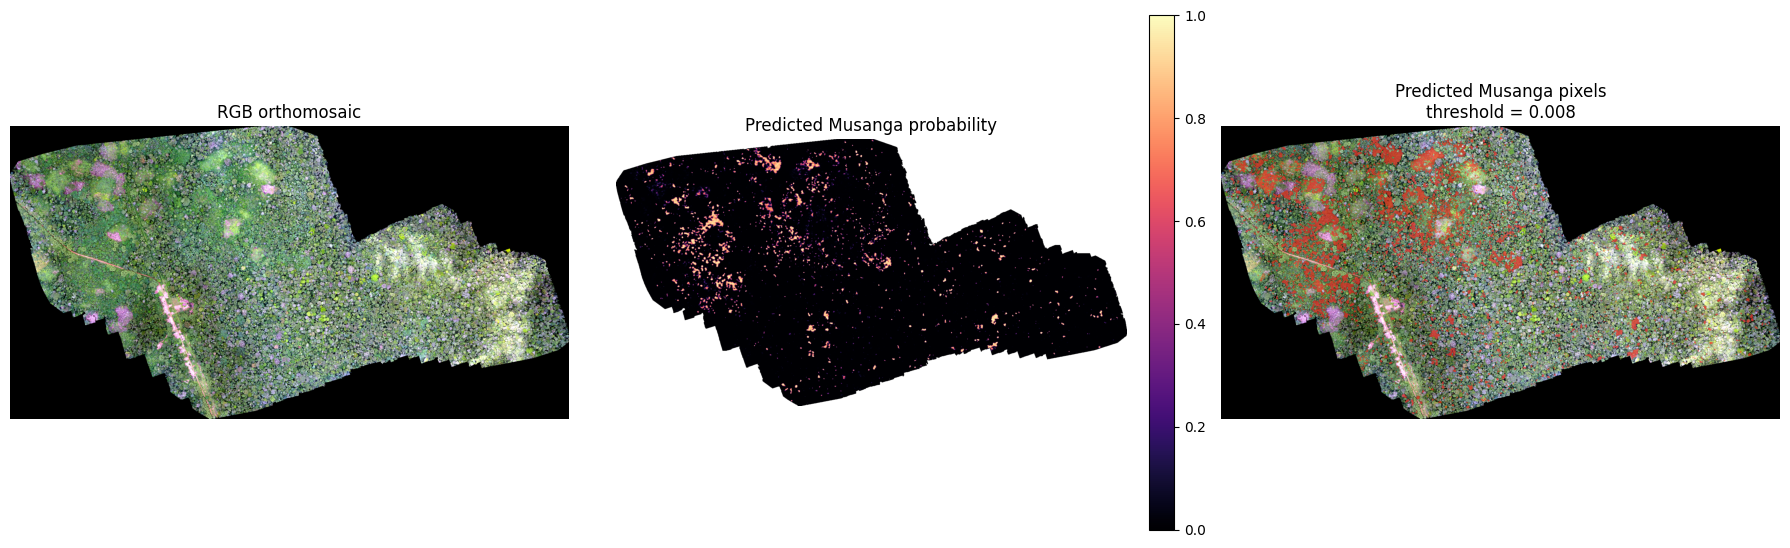


Copying completed outputs to Google Drive...
Drive copy completed in: 2.2 minutes

WHOLE-ORTHOMOSAIC INFERENCE COMPLETE

Binary Musanga raster:
/content/drive/MyDrive/Colab Notebooks/Musanga/work/whole_orthomosaic_inference/musanga_binary_mask_threshold_0.008.tif

Musanga probability raster:
/content/drive/MyDrive/Colab Notebooks/Musanga/work/whole_orthomosaic_inference/musanga_probability_uint16.tif

Overview:
/content/drive/MyDrive/Colab Notebooks/Musanga/work/whole_orthomosaic_inference/whole_orthomosaic_inference_overview.png


In [27]:
# ======================================================================================
# BLOCK 27 — OPTIMIZED WHOLE-ORTHOMOSAIC MUSANGA INFERENCE
# ======================================================================================

print("\n" + "=" * 100)
print("BLOCK 27 — OPTIMIZED WHOLE-ORTHOMOSAIC MUSANGA INFERENCE")
print("=" * 100)

from pathlib import Path
import shutil
import time

import matplotlib.pyplot as plt
import numpy as np
import rasterio
import torch

from rasterio.enums import Resampling
from rasterio.shutil import copy as rasterio_copy
from rasterio.windows import Window
from tqdm.auto import tqdm


# ----------------------------------------------------------------------
# CONFIGURATION
# ----------------------------------------------------------------------

if "BEST_LABELLED_TREE_THRESHOLD" not in globals():
    raise RuntimeError(
        "BEST_LABELLED_TREE_THRESHOLD is missing.\n"
        "Run the pixel-level threshold evaluation first."
    )

INFERENCE_THRESHOLD = float(
    BEST_LABELLED_TREE_THRESHOLD
)

INFERENCE_PATCH_SIZE = int(
    PATCH_SIZE
)

INFERENCE_HALO = 32

CORE_SIZE = (
    INFERENCE_PATCH_SIZE
    - 2 * INFERENCE_HALO
)

if CORE_SIZE <= 0:
    raise ValueError(
        "INFERENCE_HALO is too large relative to PATCH_SIZE."
    )

INFERENCE_BATCH_SIZE = (
    32
    if DEVICE.type == "cuda"
    else 2
)

SAVE_PROBABILITY_RASTER = True

PROBABILITY_SCALE = 10_000
PROBABILITY_NODATA = 65_535
MASK_NODATA = 255

OUTPUT_BLOCK_SIZE = 512

# Set True only when you intentionally want to recreate the tiled source.
FORCE_REBUILD_TILED_SOURCE = False


# ----------------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------------

ORIGINAL_RASTER_PATH = Path(
    LOCAL_RASTER_PATH
)

LOCAL_INFERENCE_DIR = Path(
    "/content/whole_orthomosaic_inference"
)

LOCAL_INFERENCE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Fast local tiled version of the source raster.
TILED_SOURCE_PATH = (
    LOCAL_INFERENCE_DIR
    / "orthomosaic_rgb_tiled_512.tif"
)

LOCAL_PROBABILITY_PATH = (
    LOCAL_INFERENCE_DIR
    / "musanga_probability_uint16.tif"
)

LOCAL_BINARY_MASK_PATH = (
    LOCAL_INFERENCE_DIR
    / (
        "musanga_binary_mask_"
        f"threshold_{INFERENCE_THRESHOLD:.3f}.tif"
    )
)

LOCAL_OVERVIEW_PATH = (
    LOCAL_INFERENCE_DIR
    / "whole_orthomosaic_inference_overview.png"
)

DRIVE_INFERENCE_DIR = (
    WORK_DIR
    / "whole_orthomosaic_inference"
)

DRIVE_INFERENCE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

DRIVE_PROBABILITY_PATH = (
    DRIVE_INFERENCE_DIR
    / LOCAL_PROBABILITY_PATH.name
)

DRIVE_BINARY_MASK_PATH = (
    DRIVE_INFERENCE_DIR
    / LOCAL_BINARY_MASK_PATH.name
)

DRIVE_OVERVIEW_PATH = (
    DRIVE_INFERENCE_DIR
    / LOCAL_OVERVIEW_PATH.name
)


# ----------------------------------------------------------------------
# VALIDATE REQUIRED OBJECTS
# ----------------------------------------------------------------------

required_objects = [
    "model",
    "DEVICE",
    "PATCH_SIZE",
    "RGB_BANDS",
    "normalize_rgb_global",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Missing required objects:\n"
        f"{missing_objects}"
    )

if not ORIGINAL_RASTER_PATH.exists():
    raise FileNotFoundError(
        f"Orthomosaic not found:\n"
        f"{ORIGINAL_RASTER_PATH}"
    )


# ----------------------------------------------------------------------
# INSPECT ORIGINAL RASTER
# ----------------------------------------------------------------------

with rasterio.open(
    ORIGINAL_RASTER_PATH
) as source:

    print("Original orthomosaic:")
    print(ORIGINAL_RASTER_PATH)

    print("\nOriginal block shapes:")
    print(source.block_shapes)

    original_width = source.width
    original_height = source.height
    original_count = source.count
    original_crs = source.crs
    original_transform = source.transform


# ----------------------------------------------------------------------
# CREATE OR REUSE A LOCALLY TILED SOURCE RASTER
# ----------------------------------------------------------------------

source_needs_rebuild = (
    FORCE_REBUILD_TILED_SOURCE
    or not TILED_SOURCE_PATH.exists()
)

if not source_needs_rebuild:

    try:

        with rasterio.open(
            TILED_SOURCE_PATH
        ) as tiled_check:

            source_needs_rebuild = not (
                tiled_check.width
                == original_width
                and tiled_check.height
                == original_height
                and tiled_check.count
                == original_count
                and tiled_check.block_shapes[0]
                == (
                    OUTPUT_BLOCK_SIZE,
                    OUTPUT_BLOCK_SIZE,
                )
            )

    except Exception:

        source_needs_rebuild = True


if source_needs_rebuild:

    if TILED_SOURCE_PATH.exists():
        TILED_SOURCE_PATH.unlink()

    print(
        "\nCreating optimized local tiled orthomosaic..."
    )
    print(
        "This is a one-time preprocessing step."
    )

    tiling_start = time.time()

    rasterio_copy(
        ORIGINAL_RASTER_PATH,
        TILED_SOURCE_PATH,
        driver="GTiff",
        tiled=True,
        blockxsize=OUTPUT_BLOCK_SIZE,
        blockysize=OUTPUT_BLOCK_SIZE,
        compress="LZW",
        predictor=2,
        BIGTIFF="YES",
        copy_src_overviews=True,
    )

    tiling_minutes = (
        time.time()
        - tiling_start
    ) / 60

    print(
        "Tiled source created in:",
        f"{tiling_minutes:.1f} minutes",
    )

else:

    print(
        "\nReusing existing optimized tiled source:"
    )
    print(TILED_SOURCE_PATH)


with rasterio.open(
    TILED_SOURCE_PATH
) as source:

    raster_height = int(
        source.height
    )

    raster_width = int(
        source.width
    )

    source_transform = source.transform
    source_crs = source.crs

    print("\nOptimized source block shapes:")
    print(source.block_shapes)


print("\nInference settings:")
print("Device:", DEVICE)
print("Patch size:", INFERENCE_PATCH_SIZE)
print("Halo:", INFERENCE_HALO)
print("Written core size:", CORE_SIZE)
print("Batch size:", INFERENCE_BATCH_SIZE)
print("Threshold:", INFERENCE_THRESHOLD)
print(
    "Save probability raster:",
    SAVE_PROBABILITY_RASTER,
)

print("\nRaster dimensions:")
print(
    f"  width:  {raster_width:,}"
)
print(
    f"  height: {raster_height:,}"
)
print(
    "  total pixels:",
    f"{raster_width * raster_height:,}",
)


# ----------------------------------------------------------------------
# BUILD OUTPUT CORE WINDOWS
# ----------------------------------------------------------------------

core_windows = []

for core_row in range(
    0,
    raster_height,
    CORE_SIZE,
):

    core_height = min(
        CORE_SIZE,
        raster_height - core_row,
    )

    for core_col in range(
        0,
        raster_width,
        CORE_SIZE,
    ):

        core_width = min(
            CORE_SIZE,
            raster_width - core_col,
        )

        core_windows.append(
            {
                "core_row": int(
                    core_row
                ),
                "core_col": int(
                    core_col
                ),
                "core_height": int(
                    core_height
                ),
                "core_width": int(
                    core_width
                ),
            }
        )


n_batches = int(
    np.ceil(
        len(core_windows)
        / INFERENCE_BATCH_SIZE
    )
)

print(
    "\nInference cores:",
    f"{len(core_windows):,}",
)

print(
    "GPU batches:",
    f"{n_batches:,}",
)


# ----------------------------------------------------------------------
# OUTPUT RASTER PROFILES
# ----------------------------------------------------------------------

common_profile = {
    "driver": "GTiff",
    "height": raster_height,
    "width": raster_width,
    "count": 1,
    "crs": source_crs,
    "transform": source_transform,
    "tiled": True,
    "blockxsize": OUTPUT_BLOCK_SIZE,
    "blockysize": OUTPUT_BLOCK_SIZE,
    "BIGTIFF": "YES",
}

probability_profile = {
    **common_profile,
    "dtype": "uint16",
    "nodata": PROBABILITY_NODATA,
}

mask_profile = {
    **common_profile,
    "dtype": "uint8",
    "nodata": MASK_NODATA,
}


# ----------------------------------------------------------------------
# REMOVE INCOMPLETE LOCAL OUTPUTS
# ----------------------------------------------------------------------

output_paths = [
    LOCAL_BINARY_MASK_PATH,
    LOCAL_OVERVIEW_PATH,
]

if SAVE_PROBABILITY_RASTER:
    output_paths.append(
        LOCAL_PROBABILITY_PATH
    )

for output_path in output_paths:

    if output_path.exists():

        output_path.unlink()

        print(
            "Removed previous output:",
            output_path,
        )


# ----------------------------------------------------------------------
# GPU SETUP
# ----------------------------------------------------------------------

model.eval()

if DEVICE.type == "cuda":

    torch.backends.cudnn.benchmark = True

    print("\nGPU:")
    print(
        torch.cuda.get_device_name(0)
    )


# ----------------------------------------------------------------------
# WHOLE-ORTHOMOSAIC INFERENCE
# ----------------------------------------------------------------------

start_time = time.time()

with rasterio.Env(
    GDAL_CACHEMAX=4096,
    NUM_THREADS="ALL_CPUS",
):

    with rasterio.open(
        TILED_SOURCE_PATH
    ) as source, rasterio.open(
        LOCAL_BINARY_MASK_PATH,
        "w",
        **mask_profile,
    ) as mask_destination:

        if SAVE_PROBABILITY_RASTER:

            probability_destination = (
                rasterio.open(
                    LOCAL_PROBABILITY_PATH,
                    "w",
                    **probability_profile,
                )
            )

            probability_destination.update_tags(
                probability_scale=(
                    1.0
                    / PROBABILITY_SCALE
                ),
                threshold=INFERENCE_THRESHOLD,
                class_name="Musanga",
                model="UNet_ResNet18",
            )

            probability_destination.scales = [
                1.0
                / PROBABILITY_SCALE
            ]

            probability_destination.offsets = [
                0.0
            ]

        else:

            probability_destination = None

        mask_destination.update_tags(
            threshold=INFERENCE_THRESHOLD,
            class_0="non_Musanga",
            class_1="Musanga",
            class_255="nodata",
            model="UNet_ResNet18",
        )

        try:

            with torch.inference_mode():

                progress = tqdm(
                    range(
                        0,
                        len(core_windows),
                        INFERENCE_BATCH_SIZE,
                    ),
                    total=n_batches,
                    desc=(
                        "Whole-orthomosaic inference"
                    ),
                )

                for batch_start in progress:

                    batch_records = (
                        core_windows[
                            batch_start:
                            batch_start
                            + INFERENCE_BATCH_SIZE
                        ]
                    )

                    n_current = len(
                        batch_records
                    )

                    batch_images = np.empty(
                        (
                            n_current,
                            3,
                            INFERENCE_PATCH_SIZE,
                            INFERENCE_PATCH_SIZE,
                        ),
                        dtype=np.float32,
                    )

                    batch_valid_masks = np.empty(
                        (
                            n_current,
                            INFERENCE_PATCH_SIZE,
                            INFERENCE_PATCH_SIZE,
                        ),
                        dtype=bool,
                    )

                    # --------------------------------------------------
                    # READ PATCHES FROM OPTIMIZED TILED TIFF
                    # --------------------------------------------------

                    for batch_row, record in enumerate(
                        batch_records
                    ):

                        input_row = (
                            record["core_row"]
                            - INFERENCE_HALO
                        )

                        input_col = (
                            record["core_col"]
                            - INFERENCE_HALO
                        )

                        input_window = Window(
                            col_off=input_col,
                            row_off=input_row,
                            width=INFERENCE_PATCH_SIZE,
                            height=INFERENCE_PATCH_SIZE,
                        )

                        raw_image = source.read(
                            RGB_BANDS,
                            window=input_window,
                            boundless=True,
                            fill_value=0,
                        )

                        # Avoid a second GDAL read through dataset_mask().
                        # Transparent/nodata areas are assumed to contain
                        # zero values in all RGB channels.
                        valid_mask = np.any(
                            raw_image != 0,
                            axis=0,
                        )

                        normalized_image = (
                            normalize_rgb_global(
                                raw_image
                            )
                        )

                        batch_images[
                            batch_row
                        ] = normalized_image

                        batch_valid_masks[
                            batch_row
                        ] = valid_mask

                    # --------------------------------------------------
                    # GPU INFERENCE
                    # --------------------------------------------------

                    image_tensor = (
                        torch.from_numpy(
                            batch_images
                        )
                        .to(
                            DEVICE,
                            non_blocking=True,
                        )
                    )

                    if DEVICE.type == "cuda":

                        with torch.autocast(
                            device_type="cuda",
                            dtype=torch.float16,
                        ):

                            logits = model(
                                image_tensor
                            )

                    else:

                        logits = model(
                            image_tensor
                        )

                    if isinstance(
                        logits,
                        dict,
                    ):

                        logits = logits.get(
                            "out",
                            logits.get("logits"),
                        )

                    if hasattr(
                        logits,
                        "logits",
                    ):

                        logits = logits.logits

                    probabilities = (
                        torch.sigmoid(
                            logits
                        )
                        .detach()
                        .float()
                        .cpu()
                        .numpy()[:, 0]
                    )

                    # --------------------------------------------------
                    # WRITE CENTRAL OUTPUT CORES
                    # --------------------------------------------------

                    for batch_row, record in enumerate(
                        batch_records
                    ):

                        core_height = record[
                            "core_height"
                        ]

                        core_width = record[
                            "core_width"
                        ]

                        row_slice = slice(
                            INFERENCE_HALO,
                            INFERENCE_HALO
                            + core_height,
                        )

                        col_slice = slice(
                            INFERENCE_HALO,
                            INFERENCE_HALO
                            + core_width,
                        )

                        core_probability = (
                            probabilities[
                                batch_row,
                                row_slice,
                                col_slice,
                            ]
                        )

                        core_valid = (
                            batch_valid_masks[
                                batch_row,
                                row_slice,
                                col_slice,
                            ]
                        )

                        binary_mask = (
                            core_probability
                            >= INFERENCE_THRESHOLD
                        ).astype(
                            np.uint8
                        )

                        binary_mask[
                            ~core_valid
                        ] = MASK_NODATA

                        output_window = Window(
                            col_off=record[
                                "core_col"
                            ],
                            row_off=record[
                                "core_row"
                            ],
                            width=core_width,
                            height=core_height,
                        )

                        mask_destination.write(
                            binary_mask,
                            1,
                            window=output_window,
                        )

                        if (
                            probability_destination
                            is not None
                        ):

                            probability_uint16 = (
                                np.clip(
                                    core_probability,
                                    0,
                                    1,
                                )
                                * PROBABILITY_SCALE
                            ).round().astype(
                                np.uint16
                            )

                            probability_uint16[
                                ~core_valid
                            ] = PROBABILITY_NODATA

                            probability_destination.write(
                                probability_uint16,
                                1,
                                window=output_window,
                            )

                    elapsed_minutes = (
                        time.time()
                        - start_time
                    ) / 60

                    progress.set_postfix(
                        elapsed=(
                            f"{elapsed_minutes:.1f} min"
                        )
                    )

                    del image_tensor
                    del logits
                    del probabilities

        finally:

            if probability_destination is not None:
                probability_destination.close()


inference_minutes = (
    time.time()
    - start_time
) / 60

print(
    "\nInference completed in:",
    f"{inference_minutes:.1f} minutes",
)


# ----------------------------------------------------------------------
# SUMMARIZE BINARY OUTPUT
# ----------------------------------------------------------------------

valid_pixels = 0
musanga_pixels = 0

with rasterio.open(
    LOCAL_BINARY_MASK_PATH
) as mask_source:

    for _, window in mask_source.block_windows(
        1
    ):

        block = mask_source.read(
            1,
            window=window,
        )

        valid = (
            block != MASK_NODATA
        )

        valid_pixels += int(
            valid.sum()
        )

        musanga_pixels += int(
            (
                block == 1
            ).sum()
        )


musanga_fraction = (
    musanga_pixels
    / max(
        valid_pixels,
        1,
    )
)

print("\n" + "-" * 100)
print("WHOLE-ORTHOMOSAIC INFERENCE SUMMARY")
print("-" * 100)

print(
    "Valid pixels:",
    f"{valid_pixels:,}",
)

print(
    "Predicted Musanga pixels:",
    f"{musanga_pixels:,}",
)

print(
    "Predicted Musanga fraction:",
    f"{musanga_fraction:.4%}",
)


# ----------------------------------------------------------------------
# CREATE LOW-RES OVERVIEW
# ----------------------------------------------------------------------

OVERVIEW_MAX_DIMENSION = 1800

with rasterio.open(
    TILED_SOURCE_PATH
) as source:

    overview_scale = min(
        1.0,
        OVERVIEW_MAX_DIMENSION
        / max(
            source.width,
            source.height,
        ),
    )

    overview_height = max(
        1,
        int(
            source.height
            * overview_scale
        ),
    )

    overview_width = max(
        1,
        int(
            source.width
            * overview_scale
        ),
    )

    rgb_overview = source.read(
        RGB_BANDS,
        out_shape=(
            3,
            overview_height,
            overview_width,
        ),
        resampling=Resampling.bilinear,
    )

    rgb_overview = (
        normalize_rgb_global(
            rgb_overview
        )
    )

    rgb_overview = np.moveaxis(
        rgb_overview,
        0,
        -1,
    )


with rasterio.open(
    LOCAL_BINARY_MASK_PATH
) as mask_source:

    mask_overview = mask_source.read(
        1,
        out_shape=(
            overview_height,
            overview_width,
        ),
        resampling=Resampling.nearest,
    )

predicted_overview = (
    mask_overview == 1
)

overlay = rgb_overview.copy()

overlay[
    predicted_overview
] = (
    0.35
    * overlay[
        predicted_overview
    ]
    + 0.65
    * np.array(
        [1.0, 0.1, 0.1]
    )
)


if SAVE_PROBABILITY_RASTER:

    with rasterio.open(
        LOCAL_PROBABILITY_PATH
    ) as probability_source:

        probability_raw = (
            probability_source.read(
                1,
                out_shape=(
                    overview_height,
                    overview_width,
                ),
                resampling=Resampling.bilinear,
            )
        )

    probability_overview = (
        probability_raw.astype(
            np.float32
        )
    )

    probability_valid = (
        probability_raw
        != PROBABILITY_NODATA
    )

    probability_overview[
        probability_valid
    ] /= PROBABILITY_SCALE

    probability_overview[
        ~probability_valid
    ] = np.nan

    figure, axes = plt.subplots(
        1,
        3,
        figsize=(18, 7),
    )

    axes[0].imshow(
        rgb_overview
    )
    axes[0].set_title(
        "RGB orthomosaic"
    )

    probability_image = axes[1].imshow(
        probability_overview,
        cmap="magma",
        vmin=0,
        vmax=1,
    )
    axes[1].set_title(
        "Predicted Musanga probability"
    )

    figure.colorbar(
        probability_image,
        ax=axes[1],
        fraction=0.046,
        pad=0.04,
    )

    axes[2].imshow(
        overlay
    )
    axes[2].set_title(
        "Predicted Musanga pixels\n"
        f"threshold = {INFERENCE_THRESHOLD:.3f}"
    )

else:

    figure, axes = plt.subplots(
        1,
        2,
        figsize=(13, 7),
    )

    axes[0].imshow(
        rgb_overview
    )
    axes[0].set_title(
        "RGB orthomosaic"
    )

    axes[1].imshow(
        overlay
    )
    axes[1].set_title(
        "Predicted Musanga pixels\n"
        f"threshold = {INFERENCE_THRESHOLD:.3f}"
    )


for axis in np.asarray(
    axes
).ravel():

    axis.axis("off")


figure.tight_layout()

figure.savefig(
    LOCAL_OVERVIEW_PATH,
    dpi=220,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


# ----------------------------------------------------------------------
# COPY COMPLETED OUTPUTS TO GOOGLE DRIVE
# ----------------------------------------------------------------------

print(
    "\nCopying completed outputs to Google Drive..."
)

copy_start = time.time()

shutil.copy2(
    LOCAL_BINARY_MASK_PATH,
    DRIVE_BINARY_MASK_PATH,
)

if SAVE_PROBABILITY_RASTER:

    shutil.copy2(
        LOCAL_PROBABILITY_PATH,
        DRIVE_PROBABILITY_PATH,
    )

shutil.copy2(
    LOCAL_OVERVIEW_PATH,
    DRIVE_OVERVIEW_PATH,
)

copy_minutes = (
    time.time()
    - copy_start
) / 60

print(
    "Drive copy completed in:",
    f"{copy_minutes:.1f} minutes",
)


# ----------------------------------------------------------------------
# FINAL OUTPUT PATHS
# ----------------------------------------------------------------------

print("\n" + "=" * 100)
print("WHOLE-ORTHOMOSAIC INFERENCE COMPLETE")
print("=" * 100)

print("\nBinary Musanga raster:")
print(DRIVE_BINARY_MASK_PATH)

if SAVE_PROBABILITY_RASTER:

    print("\nMusanga probability raster:")
    print(DRIVE_PROBABILITY_PATH)

print("\nOverview:")
print(DRIVE_OVERVIEW_PATH)